In [103]:
import pandas as pd
import numpy as np 
import hashlib
import matplotlib.pyplot as plt
import re

## Construção do dataset do TCC

Vamos iniciar com os seguintes to do:

- Entendimento das bases e identificando novas features com os 3 datasets principais
- Identificar chaves conectando essas fontes
- Criar desenho que conecta os dataset
- Iniciar um EDA


In [104]:
# Carregar as fontes:

raw_fighter_details = pd.read_csv(r'C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\3.ufc_datalab\raw_fighter_details.csv')

###Scrape
event_details = pd.read_csv(r'C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\1.scrape_ufc_stats\event_details.csv')
fight_details = pd.read_csv(r'C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\1.scrape_ufc_stats\fight_details.csv')
fight_results = pd.read_csv(r'C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\1.scrape_ufc_stats\fight_results.csv')
fight_stats = pd.read_csv(r'C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\1.scrape_ufc_stats\fight_stats.csv')


### dim_fighter
dim_fighter = pd.read_csv(r'C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_silver\dim_fighters.csv')

### dim_fight

dim_fight = pd.read_csv(r'C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_silver\dim_fight.csv')

C:\Users\edude\AppData\Local\Temp\ipykernel_15668\1801288967.py:17: DtypeWarning: Columns (60,61,108,109,117) have mixed types. Specify dtype option on import or set low_memory=False.
  dim_fight = pd.read_csv(r'C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_silver\dim_fight.csv')


### Estrutura final ficaria desse jeito:

`dim_fights` (C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_silver\dim_fight.csv)

    ↓
base central de lutas e resultados 

-----

`fight_stats` (C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\1.scrape_ufc_stats\fight_stats.csv)

    ↓
features históricas round-a-round calculadas 

-----

`dim_fighters` (C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_silver\dim_fighters.csv)

    ↓

dados físicos/cadastrais: idade, altura, peso, reach, stance

-----
 
-----

`raw_fighter_details` (C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\3.ufc_datalab\raw_fighter_details.csv)

    ↓

validação externa, clusterização e sanity check de perfil

### Chaves

In [105]:
dim_fighter_unique = dim_fighter.drop_duplicates(
    subset=["fighter_key"],
    keep="first"
)

In [106]:
fighter_id_map = dim_fighter_unique.set_index("fighter_key")["fighter_id"]

In [107]:
dim_fight["red_fighter_id"] = dim_fight["red_key"].map(fighter_id_map)
dim_fight["blue_fighter_id"] = dim_fight["blue_key"].map(fighter_id_map)

In [108]:
df_master = pd.DataFrame(dim_fight)
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8737 entries, 0 to 8736
Columns: 150 entries, red_fighter_name to blue_fighter_id
dtypes: float64(58), int64(44), object(48)
memory usage: 10.0+ MB


In [109]:
df_master.shape

(8737, 150)

In [110]:
dados_removidos = ['red_fighter_nickname','blue_fighter_nickname','red_fighter_key','blue_fighter_key', ## Removendo dados string do lutador após termos o identificado pelo id 
'fight_outcome','time', ## Temos esses dados em outras variaveis
'referee','details' ## Informações escritas sobre a luta sem utilidade
]

df_master = df_master.drop(columns=dados_removidos, errors='ignore')

In [111]:
df_master.dtypes.value_counts()

float64    58
int64      44
object     42
Name: count, dtype: int64

In [112]:
colunas_numericas = df_master.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = df_master.select_dtypes(include='object').columns.tolist()

print("Numéricas:", len(colunas_numericas))
print("Categóricas:", len(colunas_categoricas))

Numéricas: 102
Categóricas: 42


In [113]:
df_master[colunas_categoricas].describe()

,red_fighter_name,blue_fighter_name,event_date,red_fighter_result,blue_fighter_result,method,time_format,bout_type,bonus,event_name,...,blue_fighter_total_pts,red_key,blue_key,date_key,location,country,better_rank,odds_match,red_fighter_id,blue_fighter_id
count,8737,8737,8737,8737,8737,8737,8737,8737,2525,8737,...,2051,8737,8737,8737,6829,6829,6393,8737,8727,8732
unique,1986,2516,774,4,4,10,19,123,5,779,...,185,1986,2516,774,154,29,3,2,1982,2512
top,JIM MILLER,JEREMY STEPHENS,2016-11-19,W,L,Decision - Unanimous,3 Rnd (5-5-5),Lightweight Bout,perf,UFC 2: No Way Out,...,- - -,JIM MILLER,JEREMY STEPHENS,2016-11-19,"Las Vegas, Nevada, USA",USA,neither,both,d1941565abf50b16,18968f97ad34f15c
freq,37,22,25,5498,5498,3146,7720,1401,1203,15,...,472,37,22,25,2299,4594,4441,6829,37,22


In [114]:
df_master[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
round,8737.0,2.356988,1.016325,1.0,1.0,3.0,3.00,5.0
red_fighter_kd,8737.0,0.244935,0.515759,0.0,0.0,0.0,0.00,5.0
blue_fighter_kd,8737.0,0.185189,0.464929,0.0,0.0,0.0,0.00,6.0
red_fighter_sig_str_pct,8698.0,47.906415,15.954747,0.0,38.0,47.0,57.00,100.0
blue_fighter_sig_str_pct,8679.0,43.820832,16.754860,0.0,33.0,44.0,53.00,100.0
...,...,...,...,...,...,...,...,...
blue_lightweight_rank,132.0,8.075758,4.093602,1.0,5.0,8.0,11.00,15.0
blue_featherweight_rank,134.0,7.977612,4.430697,0.0,4.0,9.0,12.00,15.0
blue_bantamweight_rank,134.0,8.223881,4.378076,0.0,4.0,9.0,12.00,15.0
blue_flyweight_rank,140.0,8.378571,4.272158,1.0,5.0,8.0,12.00,15.0


In [115]:
nulos = df_master.isnull().sum().sort_values(ascending=False)

nulos[nulos > 0]

blue_women_s_featherweight_rank    8736
red_women_s_featherweight_rank     8731
blue_women_s_flyweight_rank        8668
blue_pound_for_pound_rank          8659
blue_women_s_strawweight_rank      8649
red_women_s_flyweight_rank         8641
blue_women_s_bantamweight_rank     8623
red_women_s_strawweight_rank       8607
blue_light_heavyweight_rank        8607
blue_welterweight_rank             8606
blue_lightweight_rank              8605
blue_featherweight_rank            8603
blue_bantamweight_rank             8603
blue_flyweight_rank                8597
blue_middleweight_rank             8588
blue_heavyweight_rank              8581
red_women_s_bantamweight_rank      8578
red_heavyweight_rank               8542
red_featherweight_rank             8541
red_lightweight_rank               8540
red_middleweight_rank              8539
red_light_heavyweight_rank         8536
red_flyweight_rank                 8534
red_bantamweight_rank              8534
red_welterweight_rank              8531


In [116]:
df_master[['red_fighter_sig_str','red_fighter_sig_str_head','red_fighter_sig_str_body','red_fighter_sig_str_leg','red_fighter_sig_str_ground','red_fighter_sig_str_clinch','red_fighter_sig_str_distance','red_fighter_sig_str']]

,red_fighter_sig_str,red_fighter_sig_str_head,red_fighter_sig_str_body,red_fighter_sig_str_leg,red_fighter_sig_str_ground,red_fighter_sig_str_clinch,red_fighter_sig_str_distance,red_fighter_sig_str
0,6 of 8,6 of 8,0 of 0,0 of 0,5 of 7,0 of 0,1 of 1,6 of 8
1,10 of 27,5 of 20,4 of 5,1 of 2,0 of 1,1 of 1,9 of 25,10 of 27
2,28 of 51,15 of 34,7 of 10,6 of 7,9 of 13,1 of 1,18 of 37,28 of 51
3,69 of 159,59 of 148,9 of 10,1 of 1,0 of 0,4 of 4,65 of 155,69 of 159
4,71 of 107,16 of 44,26 of 32,29 of 31,0 of 1,10 of 13,61 of 93,71 of 107
...,...,...,...,...,...,...,...,...
8732,0 of 0,0 of 0,0 of 0,0 of 0,0 of 0,0 of 0,0 of 0,0 of 0
8733,2 of 4,0 of 0,0 of 0,2 of 4,0 of 0,0 of 0,2 of 4,2 of 4
8734,4 of 4,3 of 3,0 of 0,1 of 1,3 of 3,1 of 1,0 of 0,4 of 4
8735,0 of 0,0 of 0,0 of 0,0 of 0,0 of 0,0 of 0,0 of 0,0 of 0


In [117]:
# ============================================================
# CONVERSÃO DE TIPOS — ANTES DO FEATURE ENGINEERING
# ============================================================

# 1. CONVERTER TEMPO DE CONTROLE (ctrl) — "0:03" → 3 segundos
def tempo_para_segundos(valor):
    # Ausência ou formato inválido não significam zero de controle.
    if pd.isna(valor):
        return np.nan
    partes = str(valor).strip().split(':')
    if len(partes) != 2 or not all(p.isascii() and p.isdigit() for p in partes):
        return np.nan
    minutos, segundos = map(int, partes)
    if segundos >= 60:
        return np.nan
    return minutos * 60 + segundos

df_master['red_fighter_ctrl_segundo'] = df_master['red_fighter_ctrl'].apply(tempo_para_segundos)
df_master['blue_fighter_ctrl_segundo'] = df_master['blue_fighter_ctrl'].apply(tempo_para_segundos)


In [118]:
# Remover colunas que são identicas a outras da base ou que não trazem informações relevantes
df_master = df_master.drop(columns = ['location','empty_arena','red_fighter_total_str','blue_fighter_total_str','red_fighter_td_pct' ,'blue_fighter_td_pct'], axis=1)

### Algumas perguntas que foram feitas na última reunião com a equipe

- Dados nulos e duplicados
- Se temos dados de lutadoras femininas

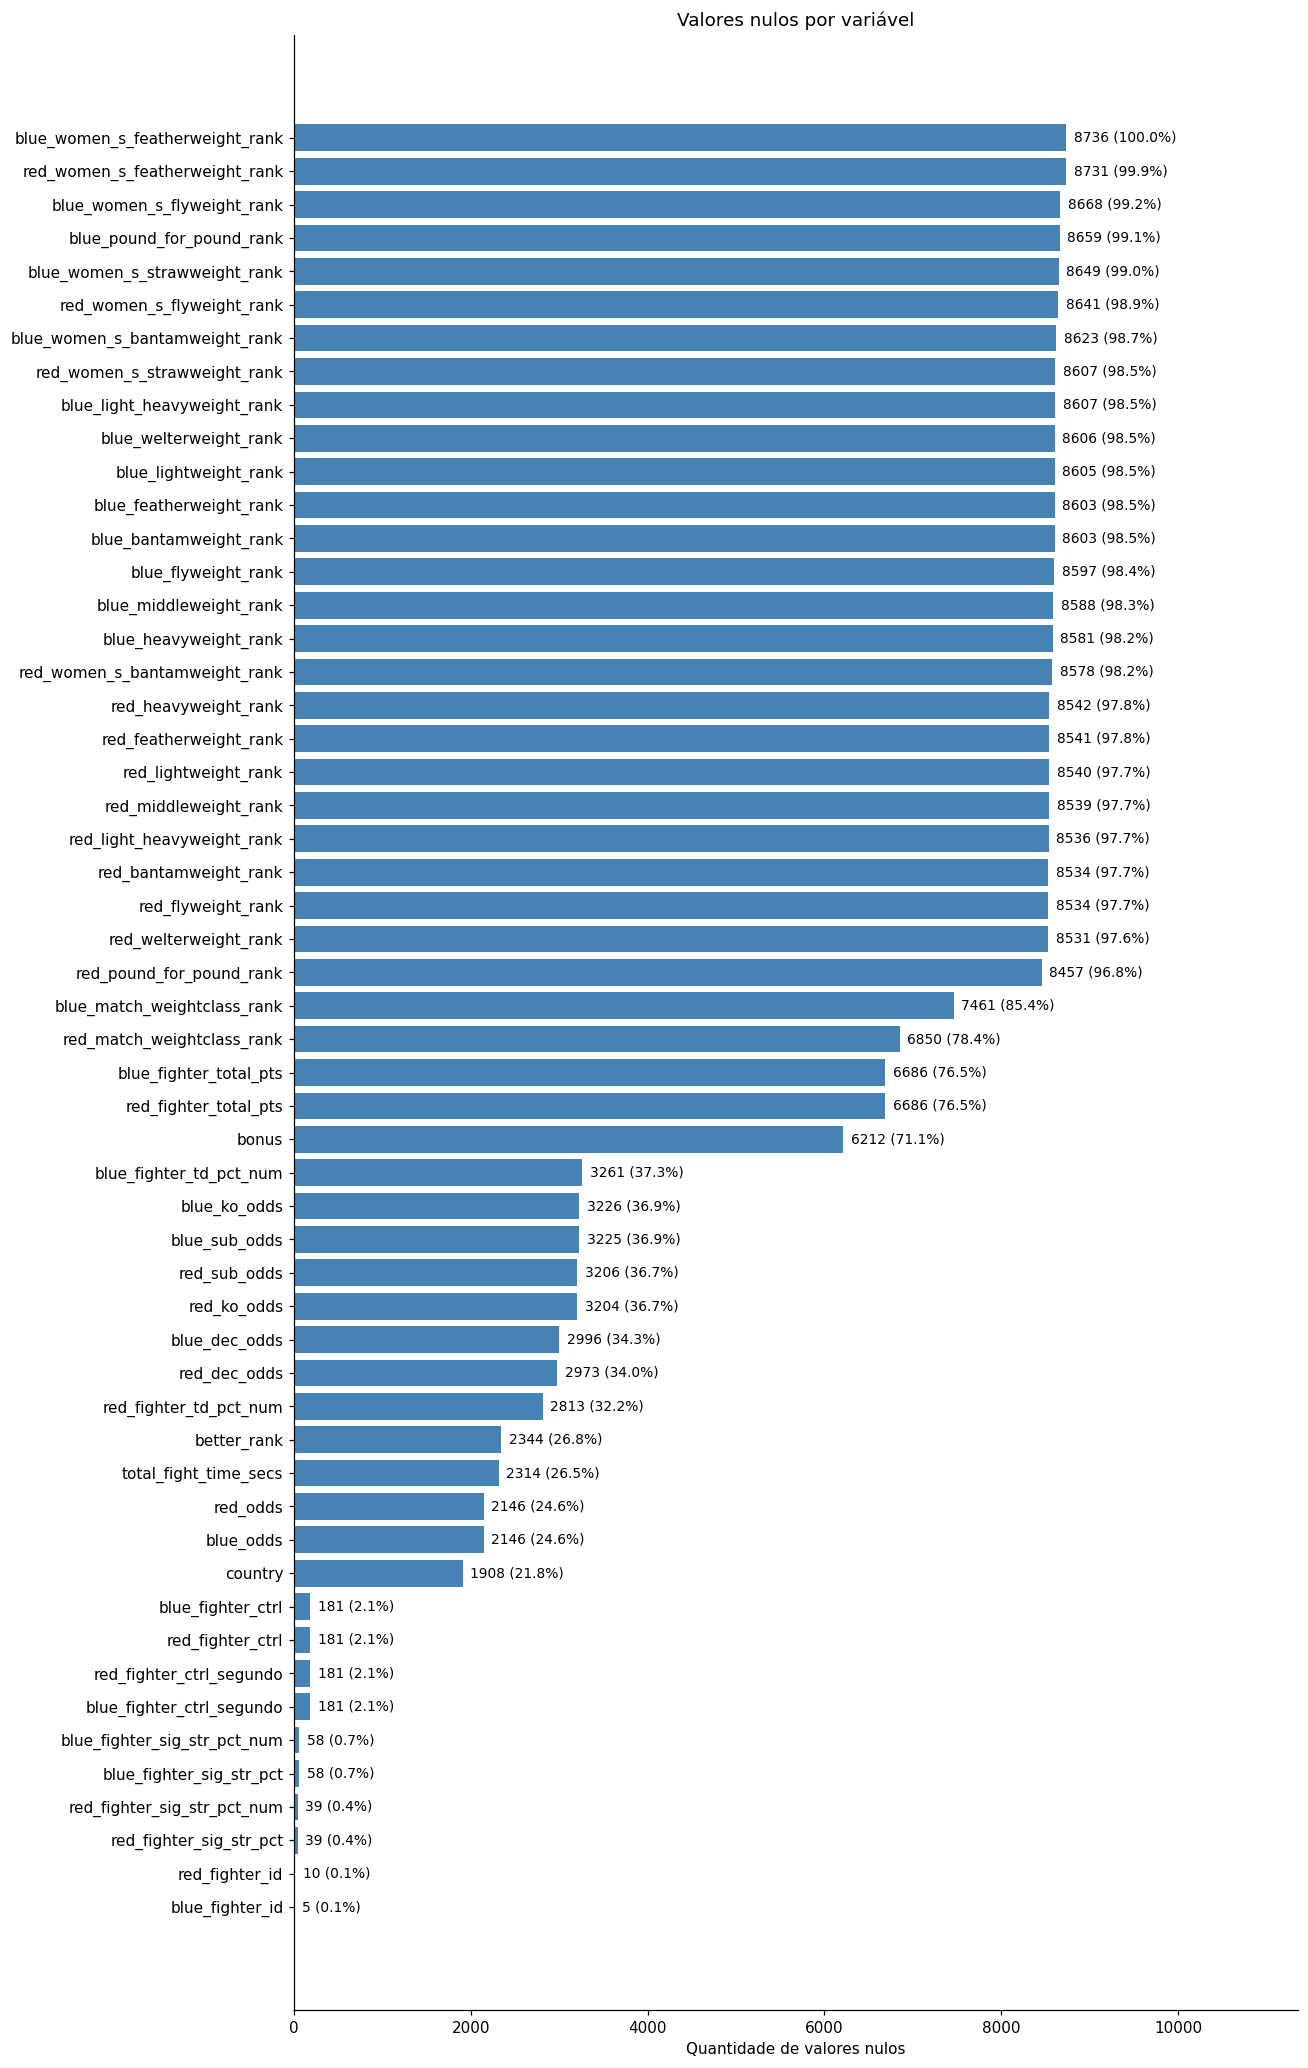

In [119]:
# Quantidade e porcentagem de nulos
nulos = df_master.isna().sum()
nulos = nulos[nulos > 0].sort_values()
percentuais = nulos / len(df_master) * 100

if nulos.empty:
    print("Não há valores nulos na base.")
else:
    fig, ax = plt.subplots(figsize=(12, max(4, len(nulos) * 0.35)))

    barras = ax.barh(nulos.index, nulos.values, color="steelblue")

    ax.bar_label(
        barras,
        labels=[
            f"{qtd} ({pct:.1f}%)"
            for qtd, pct in zip(nulos, percentuais)
        ],
        padding=5,
        fontsize=9
    )

    ax.set_title("Valores nulos por variável")
    ax.set_xlabel("Quantidade de valores nulos")
    ax.set_ylabel("")
    ax.set_xlim(0, nulos.max() * 1.3)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

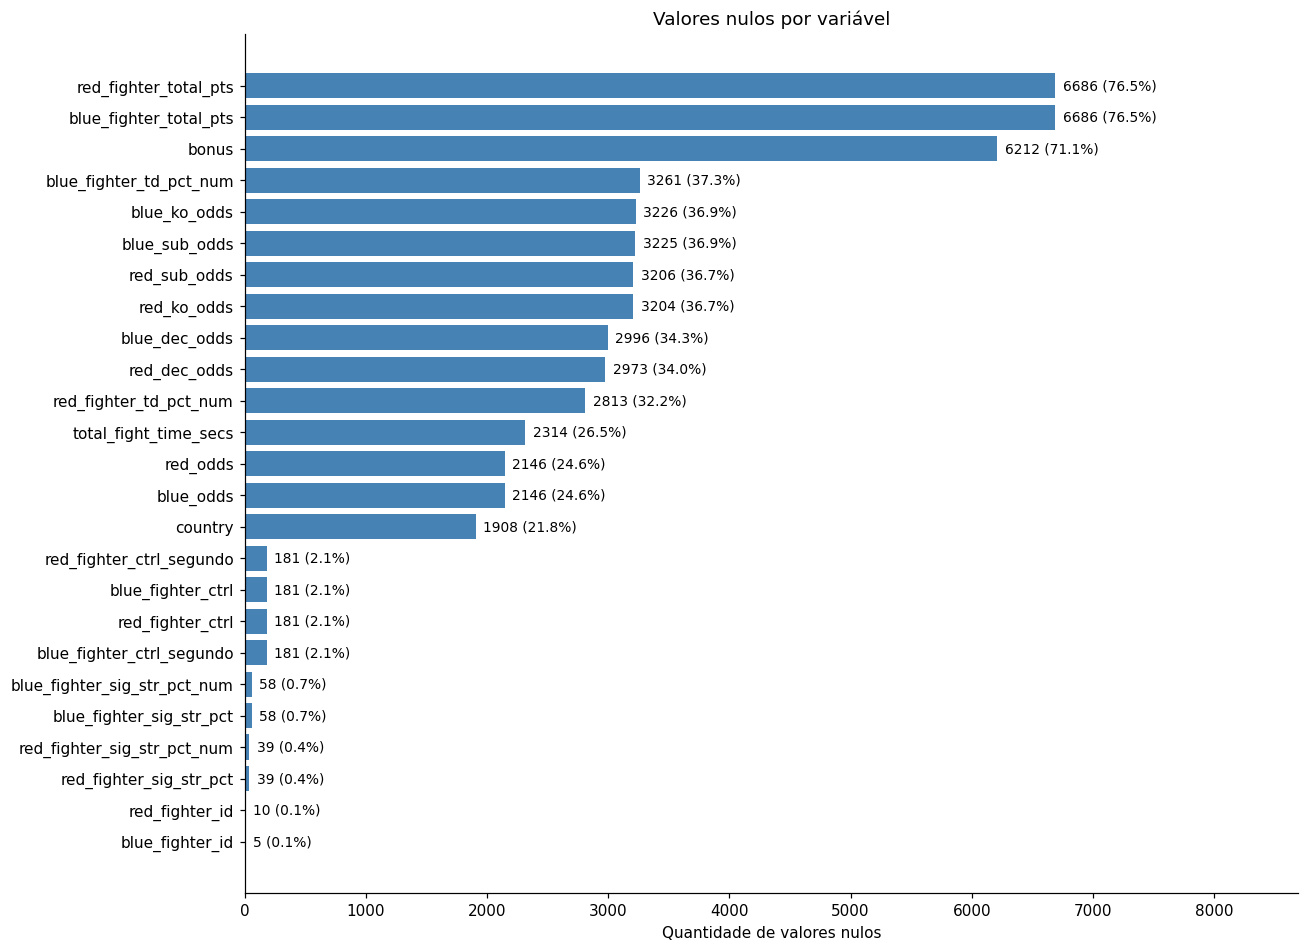

In [120]:

# Remover variáveis que contêm "rank" no nome
df_master_sem_rank = df_master.loc[
    :, ~df_master.columns.str.contains("rank", case=False, na=False)
].copy()

# Quantidade e porcentagem de nulos
nulos = df_master_sem_rank.isna().sum()
nulos = nulos[nulos > 0].sort_values()
percentuais = nulos / len(df_master_sem_rank) * 100

if nulos.empty:
    print("Não há valores nulos na base.")
else:
    fig, ax = plt.subplots(figsize=(12, max(4, len(nulos) * 0.35)))

    barras = ax.barh(nulos.index, nulos.values, color="steelblue")

    ax.bar_label(
        barras,
        labels=[
            f"{qtd} ({pct:.1f}%)"
            for qtd, pct in zip(nulos, percentuais)
        ],
        padding=5,
        fontsize=9
    )

    ax.set_title("Valores nulos por variável")
    ax.set_xlabel("Quantidade de valores nulos")
    ax.set_ylabel("")
    ax.set_xlim(0, nulos.max() * 1.3)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

#### Conclusão desse ponto

- Como hoje a informação de rank e de pontos são informações mais abertas a serem nulas, existe uma possibilidade de resolver, criando variáveis como:
    - Lutadores com estratégias de ter mais lutas resolvidas por pontos
    - Dos pesos podemos apenas considerar o peso que o lutador luta, como informação principal e se ele já lutou em outra categoria acima ou abaixo.

- Pontos preocupantes seriam informações como total_fight_time_secs que seria uma descrição importante, pois trás o dados de quanto tempo durou a luta

In [121]:
df_master[df_master['total_fight_time_secs'].isnull()]

,red_fighter_name,blue_fighter_name,event_date,red_fighter_result,blue_fighter_result,method,round,time_format,bout_type,bonus,...,blue_lightweight_rank,blue_featherweight_rank,blue_bantamweight_rank,blue_flyweight_rank,blue_pound_for_pound_rank,odds_match,red_fighter_id,blue_fighter_id,red_fighter_ctrl_segundo,blue_fighter_ctrl_segundo
0,ABDUL RAKHMAN YAKHYAEV,JULIUS WALKER,2026-06-27,W,L,KO/TKO,1,3 Rnd (5-5-5),Light Heavyweight Bout,perf,...,NaN,NaN,NaN,NaN,NaN,left_only,95aff2fd8d09a5f0,6add18754930182b,3.0,0.0
1,ABUS MAGOMEDOV,MICHAL OLEKSIEJCZUK,2026-06-27,W,L,Submission,1,3 Rnd (5-5-5),Middleweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,left_only,36b8f265bcd1b7a4,0d65c432720accb9,36.0,3.0
2,ASU ALMABAYEV,CHARLES JOHNSON,2026-06-27,W,L,Submission,3,3 Rnd (5-5-5),Flyweight Bout,perf,...,NaN,NaN,NaN,NaN,NaN,left_only,8d3273573b85be09,814e5233e2acf2ee,528.0,0.0
3,BEKZAT ALMAKHAN,JEAN MATSUMOTO,2026-06-27,L,W,Decision - Unanimous,3,3 Rnd (5-5-5),Bantamweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,left_only,a4dc0f2b95df4cc1,ffd3224638c01b57,2.0,98.0
4,DANIIL DONCHENKO,THEODOR BERGGREN,2026-06-27,W,L,KO/TKO,2,3 Rnd (5-5-5),Welterweight Bout,perf,...,NaN,NaN,NaN,NaN,NaN,left_only,70dd69b6a703257e,a726c784676a50b6,27.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8732,ROYCE GRACIE,JASON DELUCIA,1994-03-11,W,L,Submission,1,No Time Limit,Open Weight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,left_only,429e7d3725852ce9,6ceff86fae4f6b3b,NaN,NaN
8733,ROYCE GRACIE,MINOKI ICHIHARA,1994-03-11,W,L,Submission,1,No Time Limit,Open Weight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,left_only,429e7d3725852ce9,4565d435005319c0,NaN,NaN
8734,ROYCE GRACIE,PATRICK SMITH,1994-03-11,W,L,KO/TKO,1,No Time Limit,UFC 2 Tournament Title Bout,belt,...,NaN,NaN,NaN,NaN,NaN,left_only,429e7d3725852ce9,46c8ec317aff28ac,NaN,NaN
8735,ROYCE GRACIE,REMCO PARDOEL,1994-03-11,W,L,Submission,1,No Time Limit,Open Weight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,left_only,429e7d3725852ce9,749685d24e2cac50,NaN,NaN


In [122]:
# Chaves para validação
chave_nomes = [
    "blue_fighter_name", "red_fighter_name", "event_date"
]

chave_ids = [
    "red_fighter_id", "blue_fighter_id", "event_date"
]

for descricao, chave in [
    ("Nomes + data", chave_nomes),
    ("IDs + data", chave_ids)
]:
    # Chaves incompletas devem ser avaliadas separadamente
    chave_completa = df_master[chave].notna().all(axis=1)
    base = df_master.loc[chave_completa]

    duplicados = base.loc[
        base.duplicated(subset=chave, keep=False)
    ].sort_values(chave)

    print(f"\nValidação: {descricao}")
    print(f"Linhas com chave incompleta: {(~chave_completa).sum()}")
    print(f"Linhas envolvidas em duplicidade: {len(duplicados)}")
    print(
        "Repetições além da primeira ocorrência:",
        base.duplicated(subset=chave, keep="first").sum()
    )

    display(duplicados)


Validação: Nomes + data
Linhas com chave incompleta: 0
Linhas envolvidas em duplicidade: 2
Repetições além da primeira ocorrência: 1


,red_fighter_name,blue_fighter_name,event_date,red_fighter_result,blue_fighter_result,method,round,time_format,bout_type,bonus,...,blue_lightweight_rank,blue_featherweight_rank,blue_bantamweight_rank,blue_flyweight_rank,blue_pound_for_pound_rank,odds_match,red_fighter_id,blue_fighter_id,red_fighter_ctrl_segundo,blue_fighter_ctrl_segundo
8601,KAZUSHI SAKURABA,MARCUS SILVEIRA,1997-12-21,NC,NC,Overturned,1,1 Rnd + OT (12-3),Heavyweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,left_only,9b5b5a75523728f3,f717b6002486f73f,NaN,NaN
8602,KAZUSHI SAKURABA,MARCUS SILVEIRA,1997-12-21,W,L,Submission,1,1 Rnd + OT (12-3),Ultimate Japan Heavyweight Tournament Title Bout,belt,...,NaN,NaN,NaN,NaN,NaN,left_only,9b5b5a75523728f3,f717b6002486f73f,NaN,NaN



Validação: IDs + data
Linhas com chave incompleta: 15
Linhas envolvidas em duplicidade: 2
Repetições além da primeira ocorrência: 1


,red_fighter_name,blue_fighter_name,event_date,red_fighter_result,blue_fighter_result,method,round,time_format,bout_type,bonus,...,blue_lightweight_rank,blue_featherweight_rank,blue_bantamweight_rank,blue_flyweight_rank,blue_pound_for_pound_rank,odds_match,red_fighter_id,blue_fighter_id,red_fighter_ctrl_segundo,blue_fighter_ctrl_segundo
8601,KAZUSHI SAKURABA,MARCUS SILVEIRA,1997-12-21,NC,NC,Overturned,1,1 Rnd + OT (12-3),Heavyweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,left_only,9b5b5a75523728f3,f717b6002486f73f,NaN,NaN
8602,KAZUSHI SAKURABA,MARCUS SILVEIRA,1997-12-21,W,L,Submission,1,1 Rnd + OT (12-3),Ultimate Japan Heavyweight Tournament Title Bout,belt,...,NaN,NaN,NaN,NaN,NaN,left_only,9b5b5a75523728f3,f717b6002486f73f,NaN,NaN


#### Conclusão desse ponto

Validando tanto com nomes e data, quanto com os id e data, tivemos apenas uma duplicação, o que é bom para análise

In [123]:
df_master = df_master[
    ~(
        (df_master['red_fighter_name'] == 'KAZUSHI SAKURABA') &
        (df_master['blue_fighter_name'] == 'MARCUS SILVEIRA') &
        (df_master['event_date'] == '1997-12-21') &
        (df_master['method'] == 'Overturned')
    )
]

In [124]:
df_master[df_master['red_women_s_bantamweight_rank'].notnull()]

,red_fighter_name,blue_fighter_name,event_date,red_fighter_result,blue_fighter_result,method,round,time_format,bout_type,bonus,...,blue_lightweight_rank,blue_featherweight_rank,blue_bantamweight_rank,blue_flyweight_rank,blue_pound_for_pound_rank,odds_match,red_fighter_id,blue_fighter_id,red_fighter_ctrl_segundo,blue_fighter_ctrl_segundo
198,AILIN PEREZ,MACY CHIASSON,2026-02-28,W,L,Decision - Unanimous,3,3 Rnd (5-5-5),Women's Bantamweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,both,06e4245d16fc5315,9cdd2da1a9104a0b,456.0,231.0
218,NORA CORNOLLE,JOSELYNE EDWARDS,2026-02-21,L,W,Submission,2,3 Rnd (5-5-5),Women's Bantamweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,both,f2b3f4ef3f780168,f9ab66e67240db7b,23.0,273.0
322,MAYRA BUENO SILVA,JACQUELINE CAVALCANTI,2025-11-08,L,W,Decision - Unanimous,3,3 Rnd (5-5-5),Women's Bantamweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,both,cc8c623cca88f54f,e3964ece586e0635,72.0,55.0
335,KETLEN VIEIRA,NORMA DUMONT,2025-11-01,L,W,Decision - Split,3,3 Rnd (5-5-5),Women's Bantamweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,both,b9706f80d005036c,d3f5d33d61cd00c9,319.0,11.0
386,MACY CHIASSON,YANA SANTOS,2025-10-04,L,W,Decision - Unanimous,3,3 Rnd (5-5-5),Women's Bantamweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,both,9cdd2da1a9104a0b,3143bf892608139a,223.0,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6405,JULIE KEDZIE,GERMAINE DE RANDAMIE,2013-07-27,L,W,Decision - Split,3,3 Rnd (5-5-5),Women's Bantamweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,both,981ab7a0576f76a0,1d239d571e342453,293.0,232.0
6406,LIZ CARMOUCHE,JESSICA ANDRADE,2013-07-27,W,L,KO/TKO,2,3 Rnd (5-5-5),Women's Bantamweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,both,51a0c09cbe9b8472,6a1901c62ab3870f,473.0,21.0
6423,ALEXIS DAVIS,ROSI SEXTON,2013-06-15,W,L,Decision - Unanimous,3,3 Rnd (5-5-5),Women's Bantamweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,both,4c2d90e335e6df19,5dfe71ade71f3a4b,405.0,363.0
6480,SARA MCMANN,SHEILA GAFF,2013-04-27,W,L,KO/TKO,1,3 Rnd (5-5-5),Women's Bantamweight Bout,NaN,...,NaN,NaN,NaN,NaN,NaN,both,7be74a12d7352df2,837d30395faca41e,228.0,1.0


#### Conclusão desse ponto

- As variaveis de ranks podem ser o indicador para colocarmos a flag de sexo e poder identificar melhor as lutadoras femininas até para entender análises focadas

In [125]:
# 1. DIFERENÇAS DE ESTATÍSTICAS DE COMBATE
df_master['diff_kd'] = df_master['red_fighter_kd'] - df_master['blue_fighter_kd']  
df_master['diff_sig_str_pct'] = df_master['red_fighter_sig_str_pct_num'] - df_master['blue_fighter_sig_str_pct_num']
df_master['diff_td_pct'] = df_master['red_fighter_td_pct_num'] - df_master['blue_fighter_td_pct_num']
df_master['diff_sub_att'] = df_master['red_fighter_sub_att'] - df_master['blue_fighter_sub_att']
df_master['diff_rev'] = df_master['red_fighter_rev'] - df_master['blue_fighter_rev']
df_master['diff_ctrl'] = df_master['red_fighter_ctrl_segundo'] - df_master['blue_fighter_ctrl_segundo']

# # 2. DIFERENÇAS DE GOLPES POR ÁREA (usando as colunas _landed convertidas)
# df_master['diff_sig_str_head'] = df_master['red_fighter_sig_str_head_landed'] - df_master['blue_fighter_sig_str_head_landed']
# df_master['diff_sig_str_body'] = df_master['red_fighter_sig_str_body_landed'] - df_master['blue_fighter_sig_str_body_landed']
# df_master['diff_sig_str_leg'] = df_master['r  ed_fighter_sig_str_leg_landed'] - df_master['blue_fighter_sig_str_leg_landed']
# df_master['diff_sig_str_distance'] = df_master['red_fighter_sig_str_distance_landed'] - df_master['blue_fighter_sig_str_distance_landed']
# df_master['diff_sig_str_clinch'] = df_master['red_fighter_sig_str_clinch_landed'] - df_master['blue_fighter_sig_str_clinch_landed']
# df_master['diff_sig_str_ground'] = df_master['red_fighter_sig_str_ground_landed'] - df_master['blue_fighter_sig_str_ground_landed']

## EDA — distribuição das lutas e associação com vitória

In [138]:
eda = df_master.copy()
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
COR = '#3274A1'


def duracao_total(linha):
    ultimo = pd.to_numeric(linha['time_seconds'], errors='coerce')
    rnd = pd.to_numeric(linha['round'], errors='coerce')
    if pd.isna(ultimo) or pd.isna(rnd) or ultimo < 0 or rnd < 1 or rnd != int(rnd):
        return np.nan
    formato = str(linha['time_format'])
    if formato == 'No Time Limit':
        return ultimo if rnd == 1 else np.nan
    match = re.search(r'\((\d+(?:-\d+)*)\)', formato)
    if not match:
        return np.nan
    limites = [int(v) * 60 for v in match.group(1).split('-')]
    rnd = int(rnd)
    if rnd > len(limites) or ultimo > limites[rnd - 1]:
        return np.nan
    return sum(limites[:rnd - 1]) + ultimo

def frequencias(serie, titulo, top=None):
    valores = serie.astype('string').fillna('Sem informação').replace('', 'Sem informação')
    tabela = valores.value_counts().rename_axis('categoria').to_frame('quantidade')
    tabela['percentual'] = tabela['quantidade'] / len(valores) * 100
    plot = tabela['quantidade'].copy()
    if top and len(plot) > top:
        plot = pd.concat([plot.iloc[:top], pd.Series({'Demais rótulos': plot.iloc[top:].sum()})])
    plot = plot.sort_values()
    fig, ax = plt.subplots(figsize=(11, max(4, len(plot) * .32)))
    barras = ax.barh(plot.index, plot, color=COR)
    ax.bar_label(barras, labels=[f'{n:,} ({n / len(valores):.1%})' for n in plot], padding=4)
    ax.set(xlabel='Quantidade de lutas', title=titulo, xlim=(0, plot.max() * 1.32))
    fig.tight_layout()
    plt.show()
    display(tabela)
    return tabela



red_result = eda['red_fighter_result'].astype('string').str.strip().str.upper()
blue_result = eda['blue_fighter_result'].astype('string').str.strip().str.upper()
decisiva = ((red_result.eq('W') & blue_result.eq('L')) |
            (red_result.eq('L') & blue_result.eq('W'))).fillna(False)
eda['red_venceu'] = red_result.eq('W').astype(float).where(decisiva)


eda['tempo_total_segundos'] = eda.apply(duracao_total, axis=1)
eda['tempo_total_minutos'] = eda['tempo_total_segundos'] / 60
eda['data_evento'] = pd.to_datetime(eda['event_date'], errors='coerce')

In [127]:
# eda = df_master.copy()
# plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
#                      'axes.spines.right': False, 'font.size': 10})
# COR = '#3274A1'

# # Excluir apenas cópias integralmente idênticas nesta base de análise.
# n_antes = len(eda)
# eda = eda.drop_duplicates().copy()
# print(f'Lutas na análise: {len(eda):,}; cópias idênticas removidas: {n_antes - len(eda)}')
# chave = ['red_fighter_name', 'blue_fighter_name', 'event_date']
# print('Linhas com nomes + data repetidos:', eda.duplicated(chave, keep=False).sum())
# eda['data_evento'] = pd.to_datetime(eda['event_date'], errors='coerce')

# def numerica(coluna):
#     return pd.to_numeric(eda[coluna], errors='coerce')

# # time_seconds é o tempo transcorrido no último round, e não a duração total.
# def duracao_total(linha):
#     ultimo = pd.to_numeric(linha['time_seconds'], errors='coerce')
#     rnd = pd.to_numeric(linha['round'], errors='coerce')
#     if pd.isna(ultimo) or pd.isna(rnd) or ultimo < 0 or rnd < 1 or rnd != int(rnd):
#         return np.nan
#     formato = str(linha['time_format'])
#     if formato == 'No Time Limit':
#         return ultimo if rnd == 1 else np.nan
#     match = re.search(r'\((\d+(?:-\d+)*)\)', formato)
#     if not match:
#         return np.nan
#     limites = [int(v) * 60 for v in match.group(1).split('-')]
#     rnd = int(rnd)
#     if rnd > len(limites) or ultimo > limites[rnd - 1]:
#         return np.nan
#     return sum(limites[:rnd - 1]) + ultimo

# eda['tempo_total_segundos'] = eda.apply(duracao_total, axis=1)
# eda['tempo_total_minutos'] = eda['tempo_total_segundos'] / 60
# fonte_total = numerica('total_fight_time_secs')
# comparaveis = fonte_total.notna() & eda['tempo_total_segundos'].notna()
# divergentes = comparaveis & ((fonte_total - eda['tempo_total_segundos']).abs() > 1)
# print('Duração total não calculável:', eda['tempo_total_segundos'].isna().sum())
# print('Divergências > 1 segundo com total_fight_time_secs:', divergentes.sum())
# if divergentes.any():
#     display(eda.loc[divergentes, chave + ['time_format', 'round', 'time_seconds',
#                                        'total_fight_time_secs', 'tempo_total_segundos']].head(10))

# red_result = eda['red_fighter_result'].astype('string').str.strip().str.upper()
# blue_result = eda['blue_fighter_result'].astype('string').str.strip().str.upper()
# decisiva = ((red_result.eq('W') & blue_result.eq('L')) |
#             (red_result.eq('L') & blue_result.eq('W'))).fillna(False)
# eda['red_venceu'] = red_result.eq('W').astype(float).where(decisiva)
# print('Lutas com vencedor definido:', decisiva.sum())

# def frequencias(serie, titulo, top=None):
#     valores = serie.astype('string').fillna('Sem informação').replace('', 'Sem informação')
#     tabela = valores.value_counts().rename_axis('categoria').to_frame('quantidade')
#     tabela['percentual'] = tabela['quantidade'] / len(valores) * 100
#     plot = tabela['quantidade'].copy()
#     if top and len(plot) > top:
#         plot = pd.concat([plot.iloc[:top], pd.Series({'Demais rótulos': plot.iloc[top:].sum()})])
#     plot = plot.sort_values()
#     fig, ax = plt.subplots(figsize=(11, max(4, len(plot) * .32)))
#     barras = ax.barh(plot.index, plot, color=COR)
#     ax.bar_label(barras, labels=[f'{n:,} ({n / len(valores):.1%})' for n in plot], padding=4)
#     ax.set(xlabel='Quantidade de lutas', title=titulo, xlim=(0, plot.max() * 1.32))
#     fig.tight_layout()
#     plt.show()
#     display(tabela)
#     return tabela

In [128]:
eda.shape

(8736, 149)

### 1. Duração total e cobertura temporal
A duração é reconstruída a partir dos rounds anteriores e do tempo do último round, respeitando `time_format`, inclusive formatos antigos. Casos inválidos permanecem ausentes. A linha da mediana resume a distribuição; o último ano da base pode estar incompleto.

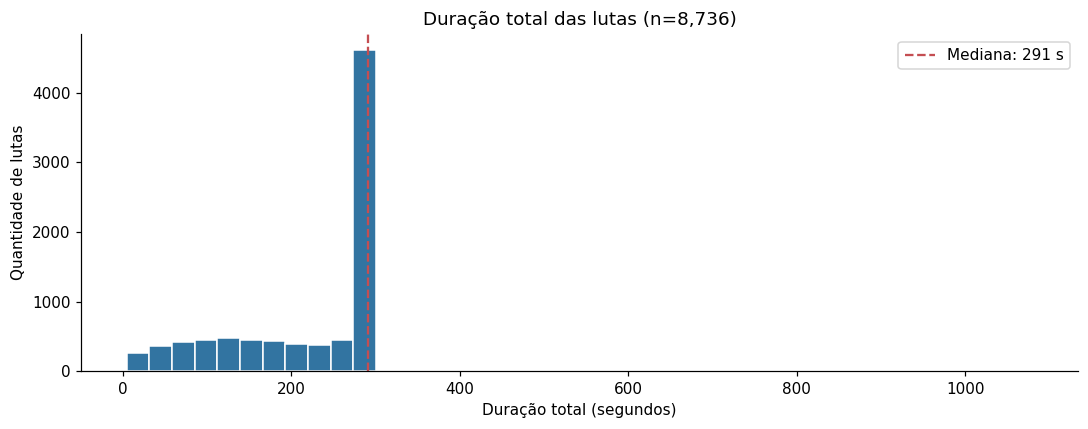

,segundos
count,8736.000000
mean,228.326236
std,96.720809
min,5.000000
25%,152.750000
50%,291.000000
75%,300.000000
max,1080.000000


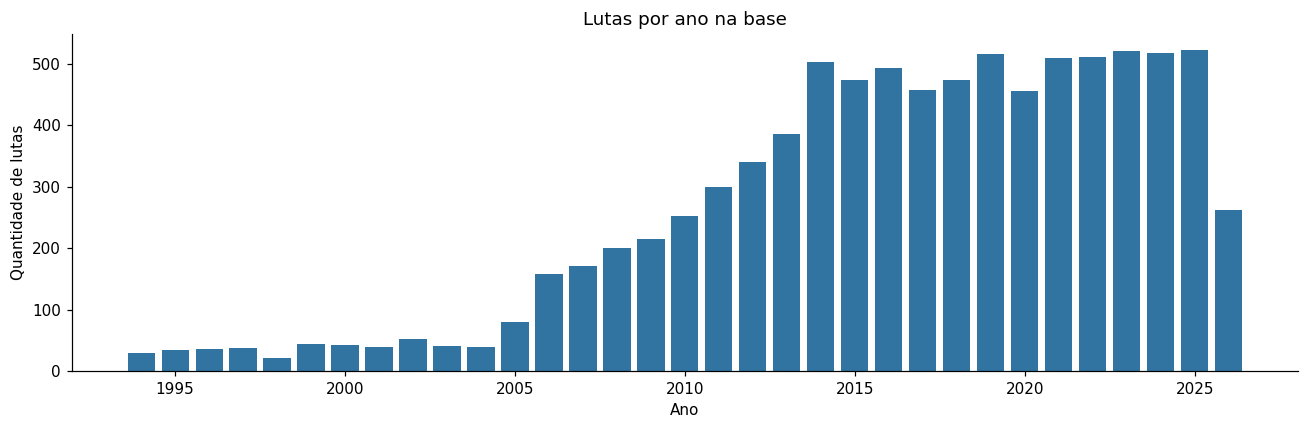

Cobertura: 1994-03-11 00:00:00 até 2026-06-27 00:00:00
Datas ausentes/inválidas: 0


In [129]:
tempos = eda['time_seconds'].dropna()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tempos, bins=40, color=COR, edgecolor='white')
ax.axvline(tempos.median(), color='#C44E52', linestyle='--',
           label=f'Mediana: {tempos.median():.0f} s')
ax.set(title=f'Duração total das lutas (n={len(tempos):,})',
       xlabel='Duração total (segundos)', ylabel='Quantidade de lutas')
ax.legend()
fig.tight_layout()
plt.show()
display(tempos.describe().to_frame('segundos'))

por_ano = eda['data_evento'].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(por_ano.index, por_ano.values, color=COR)
ax.set(title='Lutas por ano na base', xlabel='Ano', ylabel='Quantidade de lutas')
fig.tight_layout()
plt.show()
print('Cobertura:', eda['data_evento'].min(), 'até', eda['data_evento'].max())
print('Datas ausentes/inválidas:', eda['data_evento'].isna().sum())

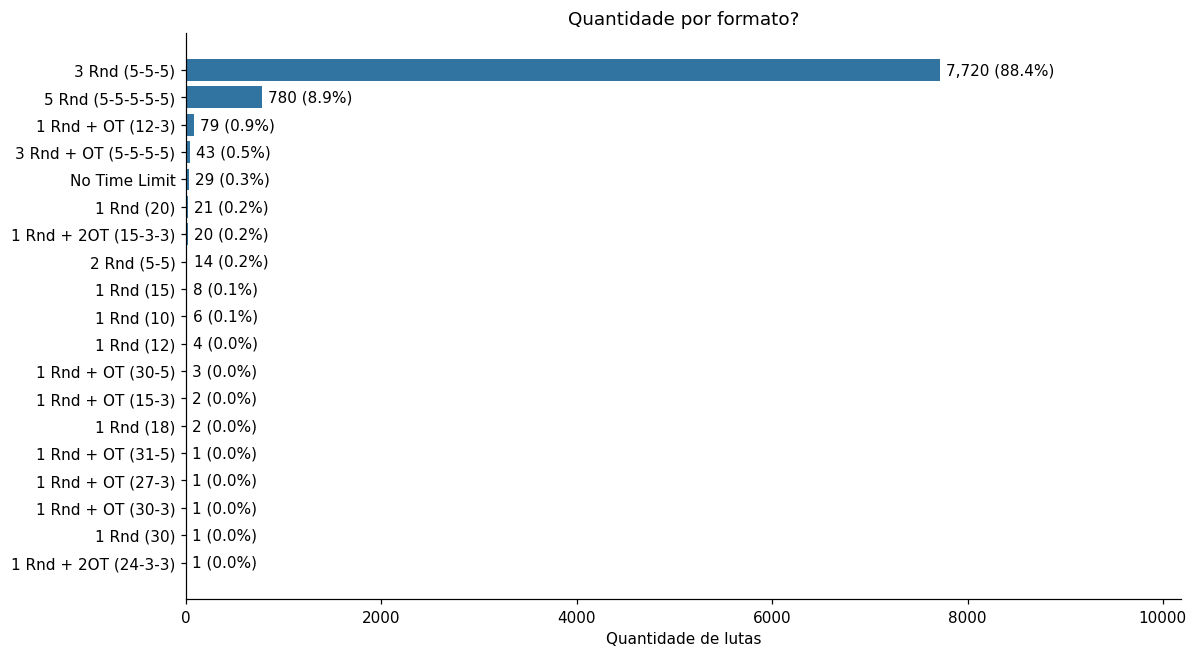

,quantidade,percentual
categoria,,
3 Rnd (5-5-5),7720,88.369963
5 Rnd (5-5-5-5-5),780,8.928571
1 Rnd + OT (12-3),79,0.904304
3 Rnd + OT (5-5-5-5),43,0.492216
No Time Limit,29,0.33196
1 Rnd (20),21,0.240385
1 Rnd + 2OT (15-3-3),20,0.228938
2 Rnd (5-5),14,0.160256
1 Rnd (15),8,0.091575


,quantidade,percentual
categoria,,
3 Rnd (5-5-5),7720,88.369963
5 Rnd (5-5-5-5-5),780,8.928571
1 Rnd + OT (12-3),79,0.904304
3 Rnd + OT (5-5-5-5),43,0.492216
No Time Limit,29,0.33196
1 Rnd (20),21,0.240385
1 Rnd + 2OT (15-3-3),20,0.228938
2 Rnd (5-5),14,0.160256
1 Rnd (15),8,0.091575


In [130]:
frequencias(eda['time_format'], 'Quantidade por formato?')

### 2. Método de término, categoria e país do evento
Percentuais usam todas as lutas da base de análise, incluindo dados ausentes. O gráfico de `bout_type` mostra os 20 rótulos mais frequentes e agrega o restante; a tabela contém todos os rótulos. País refere-se ao evento, não à nacionalidade do atleta.

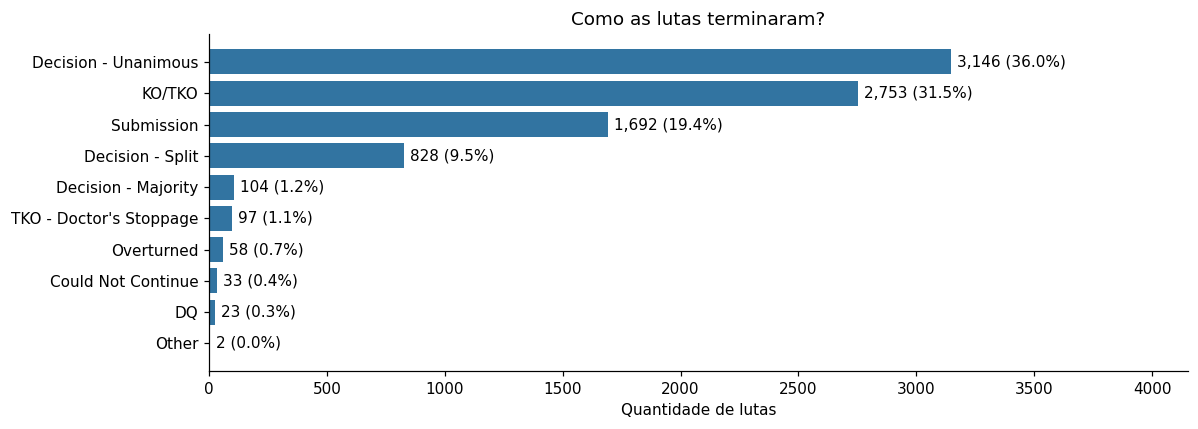

,quantidade,percentual
categoria,,
Decision - Unanimous,3146,36.011905
KO/TKO,2753,31.513278
Submission,1692,19.368132
Decision - Split,828,9.478022
Decision - Majority,104,1.190476
TKO - Doctor's Stoppage,97,1.110348
Overturned,58,0.663919
Could Not Continue,33,0.377747
DQ,23,0.263278


In [131]:
freq_method = frequencias(eda['method'], 'Como as lutas terminaram?')

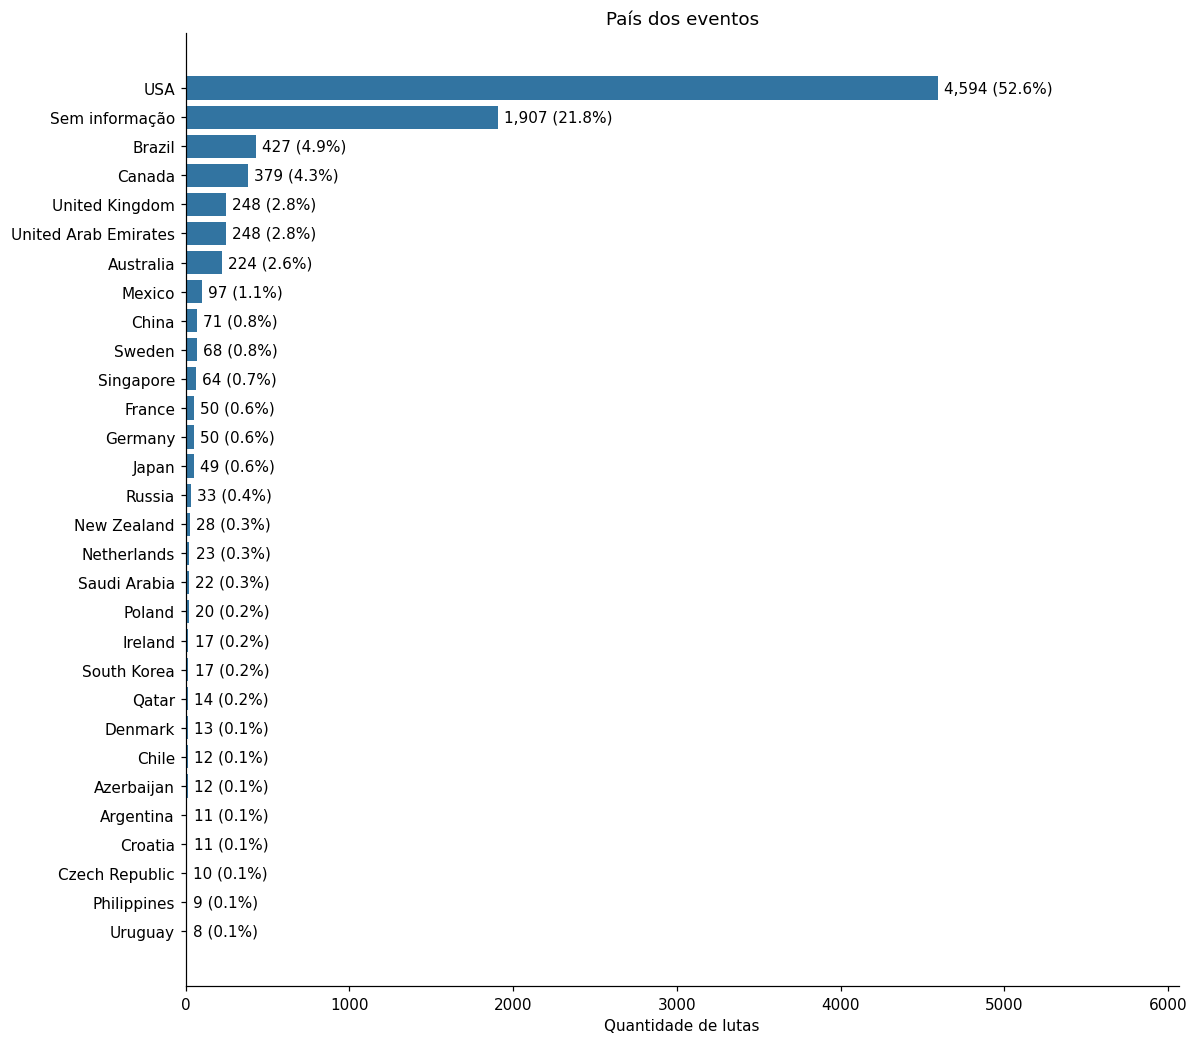

,quantidade,percentual
categoria,,
USA,4594,52.586996
Sem informação,1907,21.829212
Brazil,427,4.887821
Canada,379,4.33837
United Kingdom,248,2.838828
United Arab Emirates,248,2.838828
Australia,224,2.564103
Mexico,97,1.110348
China,71,0.812729


In [132]:
freq_country = frequencias(eda['country'], 'País dos eventos')

### 3. Melhor ranking  

Lutas analisadas: 1,950
Fora do cálculo: 6,786


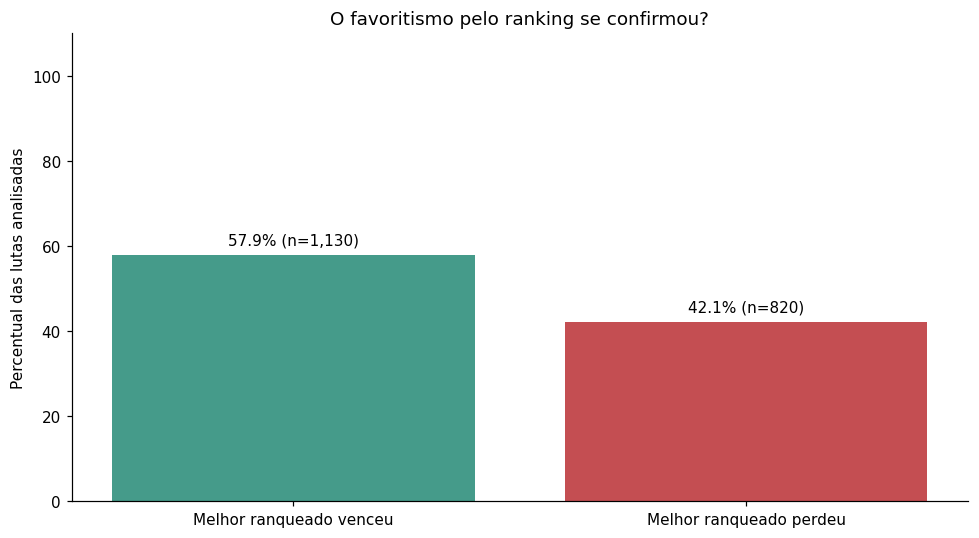

,quantidade,percentual
Melhor ranqueado venceu,1130,57.948718
Melhor ranqueado perdeu,820,42.051282


In [133]:
if "better_rank" not in eda.columns:
    print("A coluna better_rank não está disponível.")
else:
    ranking = eda["better_rank"].astype("string").str.strip().str.lower()
    red_result = eda["red_fighter_result"].astype("string").str.strip().str.upper()
    blue_result = eda["blue_fighter_result"].astype("string").str.strip().str.upper()

    vencedor_definido = (
        (red_result.eq("W") & blue_result.eq("L")) |
        (red_result.eq("L") & blue_result.eq("W"))
    ).fillna(False)

    elegiveis = ranking.isin(["red", "blue"]) & vencedor_definido
    base_rank = eda.loc[elegiveis].copy()

    confirmou = (
        (ranking.eq("red") & red_result.eq("W")) |
        (ranking.eq("blue") & blue_result.eq("W"))
    )

    base_rank["favoritismo_confirmado"] = confirmou.loc[elegiveis]

    print(f"Lutas analisadas: {len(base_rank):,}")
    print(f"Fora do cálculo: {(~elegiveis).sum():,}")

    if base_rank.empty:
        print("Não há lutas com ranking e resultado suficientes para comparar.")
    else:
        tab_rank = (
            base_rank["favoritismo_confirmado"]
            .value_counts()
            .reindex([True, False], fill_value=0)
            .rename_axis("favoritismo_confirmado")
            .to_frame("quantidade")
        )

        tab_rank.index = [
            "Melhor ranqueado venceu",
            "Melhor ranqueado perdeu"
        ]
        tab_rank["percentual"] = (
            tab_rank["quantidade"] / len(base_rank) * 100
        )

        fig, ax = plt.subplots(figsize=(9, 5))

        barras = ax.bar(
            tab_rank.index,
            tab_rank["percentual"],
            color=["#459B8A", "#C44E52"]
        )

        ax.bar_label(
            barras,
            labels=[
                f"{r.percentual:.1f}% (n={int(r.quantidade):,})"
                for r in tab_rank.itertuples()
            ],
            padding=5
        )

        ax.set(
            title="O favoritismo pelo ranking se confirmou?",
            ylabel="Percentual das lutas analisadas",
            ylim=(0, 110)
        )

        fig.tight_layout()
        plt.show()
        display(tab_rank)

### 4. Volume, precisão e associação com vitória
Cada barra responde: **entre lutas sem igualdade no indicador, qual percentual foi vencido por quem teve o maior valor?**
Tentativas e acertos referem-se a golpes significativos. Precisão é acertos/tentativas; zero tentativas produz valor ausente, não precisão zero.
As tabelas mostram vitórias, derrotas, igualdades e valores ausentes. As amostras podem variar entre indicadores; os gráficos não medem importância preditiva.

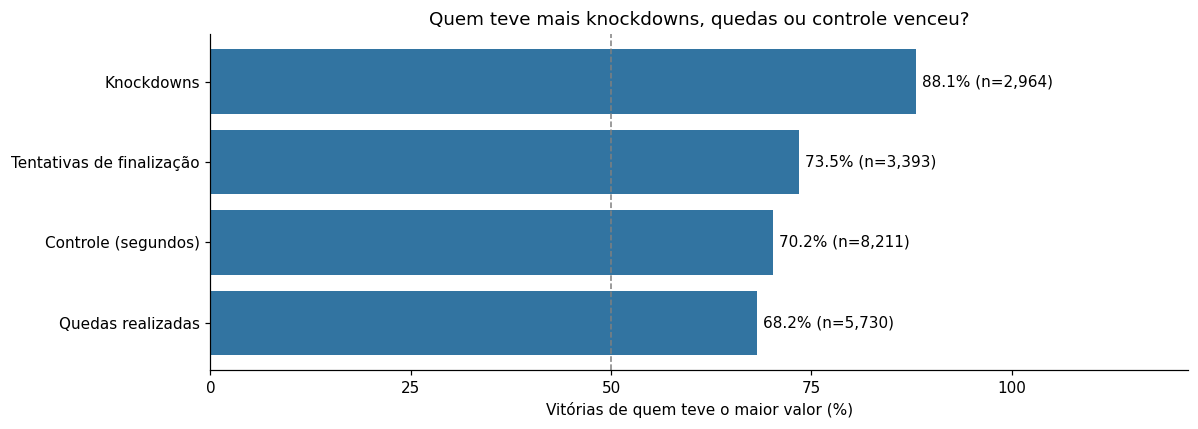

,n_comparadas,vitorias_maior,derrotas_maior,iguais,sem_dados,taxa_pct
indicador,,,,,,
Quedas realizadas,5730,3907,1823,2851,0,68.184991
Controle (segundos),8211,5764,2447,192,178,70.198514
Tentativas de finalização,3393,2494,899,5188,0,73.504274
Knockdowns,2964,2611,353,5617,0,88.090418


In [139]:
metricas = {
    'kd': 'Knockdowns',
    'sig_str_attempted': 'Golpes significativos tentados',
    'sig_str_landed': 'Golpes significativos acertados',
    'sig_str_head_landed': 'Acertos na cabeça',
    'sig_str_leg_landed': 'Acertos nas pernas',
    'td_landed': 'Quedas realizadas',
    'sub_att': 'Tentativas de finalização',
    'ctrl_segundo': 'Controle (segundos)',
}
for lado in ['red', 'blue']:
    for metrica in metricas:
        col = f'{lado}_fighter_{metrica}'
        eda[col] = pd.to_numeric(eda[col], errors='coerce').where(lambda s: s >= 0)
    for regiao in ['', '_head', '_leg']:
        prefixo = f'{lado}_fighter_sig_str{regiao}'
        acertos = pd.to_numeric(eda[prefixo + '_landed'], errors='coerce')
        tentativas = pd.to_numeric(eda[prefixo + '_attempted'], errors='coerce')
        valida = (tentativas > 0) & (acertos >= 0) & (acertos <= tentativas)
        eda[prefixo + '_precisao_eda'] = (100 * acertos / tentativas).where(valida)
metricas.update({'sig_str_precisao_eda': 'Precisão dos golpes (%)',
                 'sig_str_head_precisao_eda': 'Precisão na cabeça (%)',
                 'sig_str_leg_precisao_eda': 'Precisão nas pernas (%)'})

registros = []
for metrica, rotulo in metricas.items():
    red = eda[f'red_fighter_{metrica}']
    blue = eda[f'blue_fighter_{metrica}']
    validos = decisiva & red.notna() & blue.notna()
    iguais = pd.Series(np.isclose(red, blue, equal_nan=False), index=eda.index)
    comparar = validos & ~iguais
    venceu_maior = ((red > blue) & eda['red_venceu'].eq(1)) | ((blue > red) & eda['red_venceu'].eq(0))
    n = int(comparar.sum())
    wins = int((comparar & venceu_maior).sum())
    registros.append({'indicador': rotulo, 'n_comparadas': n, 'vitorias_maior': wins,
                      'derrotas_maior': n - wins, 'iguais': int((validos & iguais).sum()),
                      'sem_dados': int((decisiva & ~validos).sum()),
                      'taxa_pct': 100 * wins / n if n else np.nan})
    eda[f'diff_eda_{metrica}'] = red - blue
comparativo = pd.DataFrame(registros).set_index('indicador')

def grafico_taxas(rotulos, titulo):
    tabela = comparativo.loc[rotulos].sort_values('taxa_pct')
    fig, ax = plt.subplots(figsize=(11, max(4, len(tabela) * .6)))
    barras = ax.barh(tabela.index, tabela['taxa_pct'], color=COR)
    ax.bar_label(barras, labels=[f'{r.taxa_pct:.1f}% (n={r.n_comparadas:,})'
                                for r in tabela.itertuples()], padding=4)
    ax.axvline(50, color='gray', linestyle='--', linewidth=1)
    ax.set(title=titulo, xlabel='Vitórias de quem teve o maior valor (%)', xlim=(0, 122))
    ax.set_xticks([0, 25, 50, 75, 100])
    fig.tight_layout()
    plt.show()
    display(tabela)

grafico_taxas(['Knockdowns', 'Quedas realizadas', 'Tentativas de finalização', 'Controle (segundos)'],
              'Quem teve mais knockdowns, quedas ou controle venceu?')

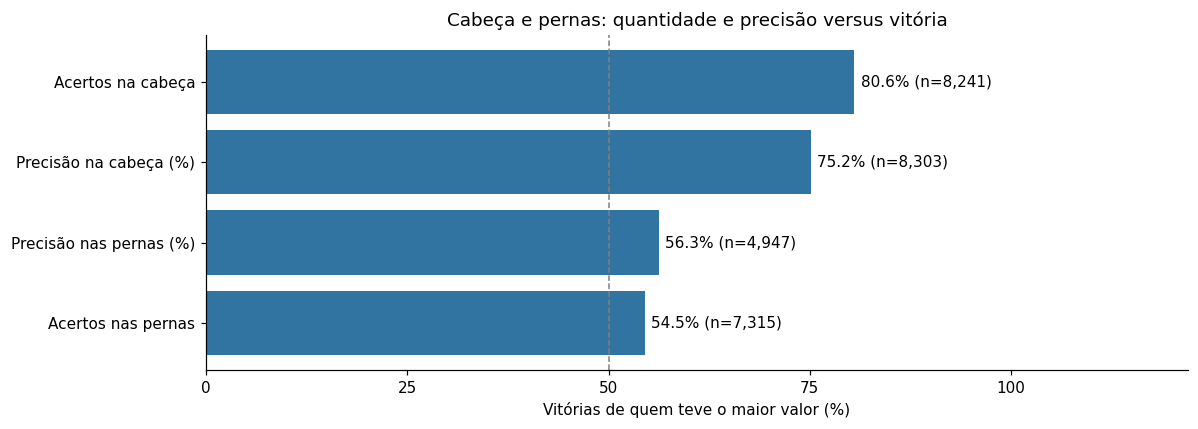

,n_comparadas,vitorias_maior,derrotas_maior,iguais,sem_dados,taxa_pct
indicador,,,,,,
Acertos nas pernas,7315,3990,3325,1266,0,54.545455
Precisão nas pernas (%),4947,2784,2163,1090,2544,56.276531
Precisão na cabeça (%),8303,6241,2062,82,196,75.165603
Acertos na cabeça,8241,6639,1602,340,0,80.560612


In [ ]:
grafico_taxas(['Acertos na cabeça', 'Acertos nas pernas',
                'Precisão na cabeça (%)', 'Precisão nas pernas (%)'],
               'Cabeça e pernas: quantidade e precisão versus vitória')

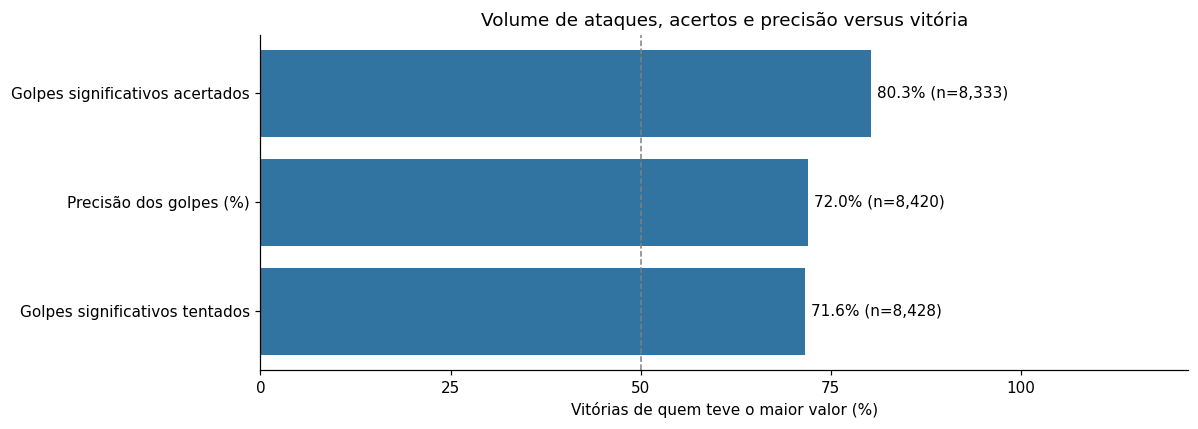

,n_comparadas,vitorias_maior,derrotas_maior,iguais,sem_dados,taxa_pct
indicador,,,,,,
Golpes significativos tentados,8428,6037,2391,153,0,71.630280
Precisão dos golpes (%),8420,6059,2361,72,89,71.959620
Golpes significativos acertados,8333,6694,1639,248,0,80.331213


In [ ]:
grafico_taxas(['Golpes significativos tentados', 'Golpes significativos acertados',
                'Precisão dos golpes (%)'],
               'Volume de ataques, acertos e precisão versus vitória')

### 6. Categorias mais leves têm maior volume de golpes?
Dois gráficos comparam **tentativas de golpes significativos**: volume por luta e ritmo por minuto. A unidade é a luta, somando os dois atletas (não o peso corporal individual).

As categorias são ordenadas da mais leve à mais pesada e separadas pelo rótulo feminino/masculino de `bout_type`, sem depender de rankings. Usamos dados desde 2001 para reduzir a mistura com categorias históricas; isso não elimina mudanças de época ou regras. Catchweight, peso aberto e rótulos não reconhecidos ficam fora dessa comparação. O primeiro gráfico usa as mesmas lutas com duração válida do segundo.

Os boxplots mostram mediana, quartis e extremos. Diferenças observadas podem também refletir época e composição da amostra. O ritmo de cada luta é `(tentativas red + tentativas blue) / minutos`; lutas curtas podem produzir taxas extremas.

Lutas incluídas: 8,409; fora do recorte: 327


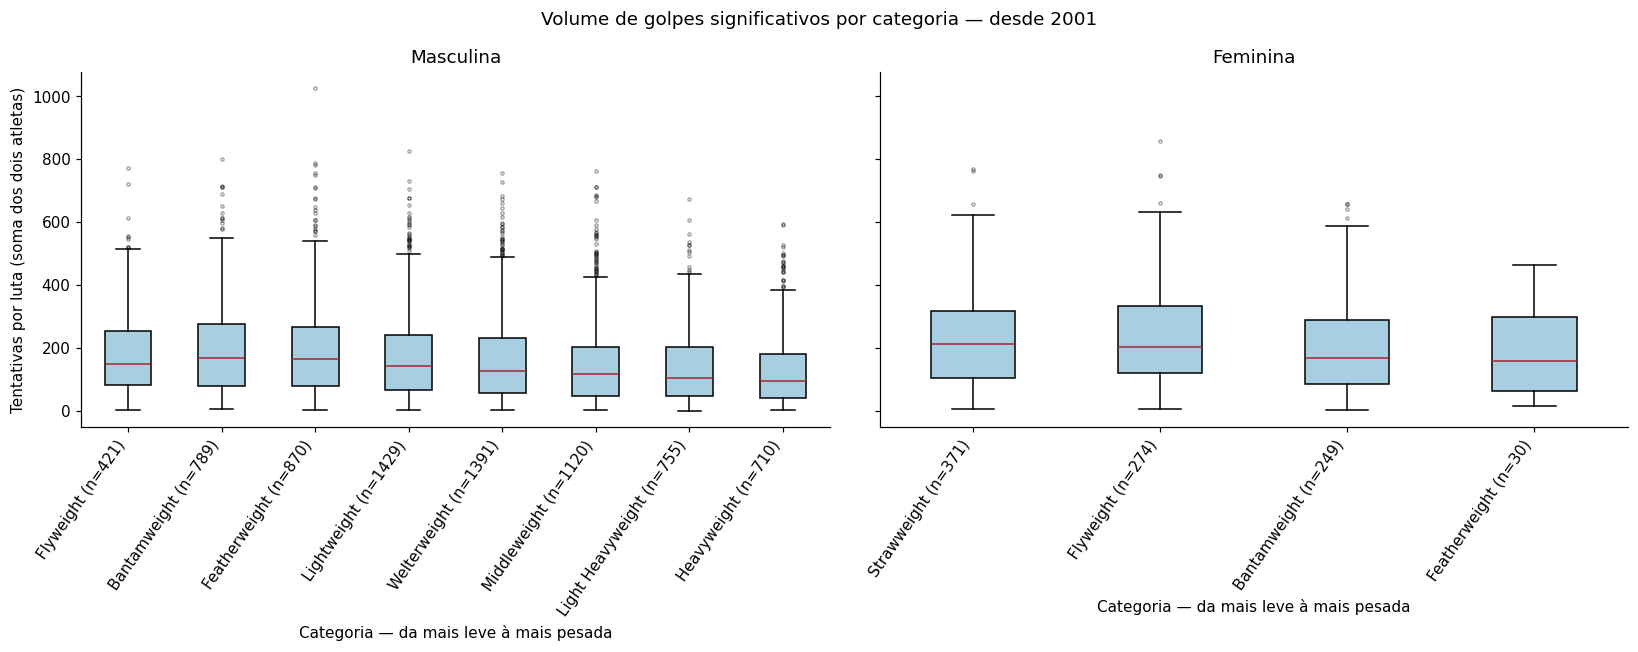

n  mediana_tentativas  \
divisao_eda categoria_peso_eda                             
Feminina    Bantamweight         249               169.0   
            Featherweight         30               159.5   
            Flyweight            274               203.0   
            Strawweight          371               211.0   
Masculina   Bantamweight         789               167.0   
            Featherweight        870               165.0   
            Flyweight            421               150.0   
            Heavyweight          710                93.0   
            Light Heavyweight    755               105.0   
            Lightweight         1429               141.0   
            Middleweight        1120               117.0   
            Welterweight        1391               127.0   

                                mediana_tentativas_min  media_tentativas_min  
divisao_eda categoria_peso_eda                                                
Feminina    Bantamweight                     15.133333             17.806773  
            Featherweight                    14.197073             15.813612  
            Flyweight                        17.841567             18.534430  
            Strawweight                      16.666667             18.064920  
Masculina   Bantamweight                     16.600000             17.588042  
            Featherweight                    16.258333             17.650266  
            Flyweight                        14.752066             16.110093  
            Heavyweight                      14.091793             16.262636  
            Light Heavyweight                14.360000             16.134795  
            Lightweight                      15.196507             16.713999  
            Middleweight                     13.600000             15.037656  
            Welterweight                     14.066667             15.829866

In [140]:
ordem_pesos = ['Strawweight', 'Flyweight', 'Bantamweight', 'Featherweight',
               'Lightweight', 'Welterweight', 'Middleweight', 'Light Heavyweight', 'Heavyweight']
def categoria_peso(valor):
    texto = str(valor)
    if any(v in texto for v in ['Catch Weight', 'Open Weight', 'Super Heavyweight']):
        return None
    # Buscar o nome mais longo primeiro evita confundir Light Heavyweight com Heavyweight.
    return next((p for p in sorted(ordem_pesos, key=len, reverse=True) if p in texto), None)

eda['categoria_peso_eda'] = eda['bout_type'].map(categoria_peso)
eda['divisao_eda'] = np.where(eda['bout_type'].astype('string').str.contains("Women's", na=False),
                             'Feminina', 'Masculina')
eda['tentativas_total_luta'] = (eda['red_fighter_sig_str_attempted'] +
                               eda['blue_fighter_sig_str_attempted'])
eda['tentativas_por_minuto'] = (eda['tentativas_total_luta'] /
                                eda['tempo_total_minutos'].where(eda['tempo_total_minutos'] > 0))
filtro_peso = (eda['data_evento'].dt.year.ge(2001) & eda['categoria_peso_eda'].notna() &
               eda['tentativas_total_luta'].notna() & eda['tentativas_por_minuto'].notna())
base_peso = eda.loc[filtro_peso].copy()
print(f'Lutas incluídas: {len(base_peso):,}; fora do recorte: {len(eda) - len(base_peso):,}')
resumo_peso = base_peso.groupby(['divisao_eda', 'categoria_peso_eda']).agg(
    n=('tentativas_total_luta', 'size'),
    mediana_tentativas=('tentativas_total_luta', 'median'),
    mediana_tentativas_min=('tentativas_por_minuto', 'median'),
    media_tentativas_min=('tentativas_por_minuto', 'mean'))

def volume_por_peso(coluna, titulo, eixo):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    for ax, divisao in zip(axes, ['Masculina', 'Feminina']):
        base = base_peso.loc[base_peso['divisao_eda'].eq(divisao)]
        categorias = [p for p in ordem_pesos if base['categoria_peso_eda'].eq(p).any()]
        amostras = [base.loc[base['categoria_peso_eda'].eq(p), coluna].dropna() for p in categorias]
        if amostras:
            ax.boxplot(amostras, patch_artist=True,
                       boxprops={'facecolor': '#A8CEE2'}, medianprops={'color': '#A32832'},
                       flierprops={'markersize': 2, 'alpha': .35})
            ax.set_xticks(range(1, len(categorias) + 1),
                          [f'{p} (n={len(a)})' for p, a in zip(categorias, amostras)],
                          rotation=55, ha='right')
        ax.set_title(divisao)
        ax.set_xlabel('Categoria — da mais leve à mais pesada')
    axes[0].set_ylabel(eixo)
    fig.suptitle(titulo)
    fig.tight_layout()
    plt.show()

volume_por_peso('tentativas_total_luta', 'Volume de golpes significativos por categoria — desde 2001',
                'Tentativas por luta (soma dos dois atletas)')
display(resumo_peso)

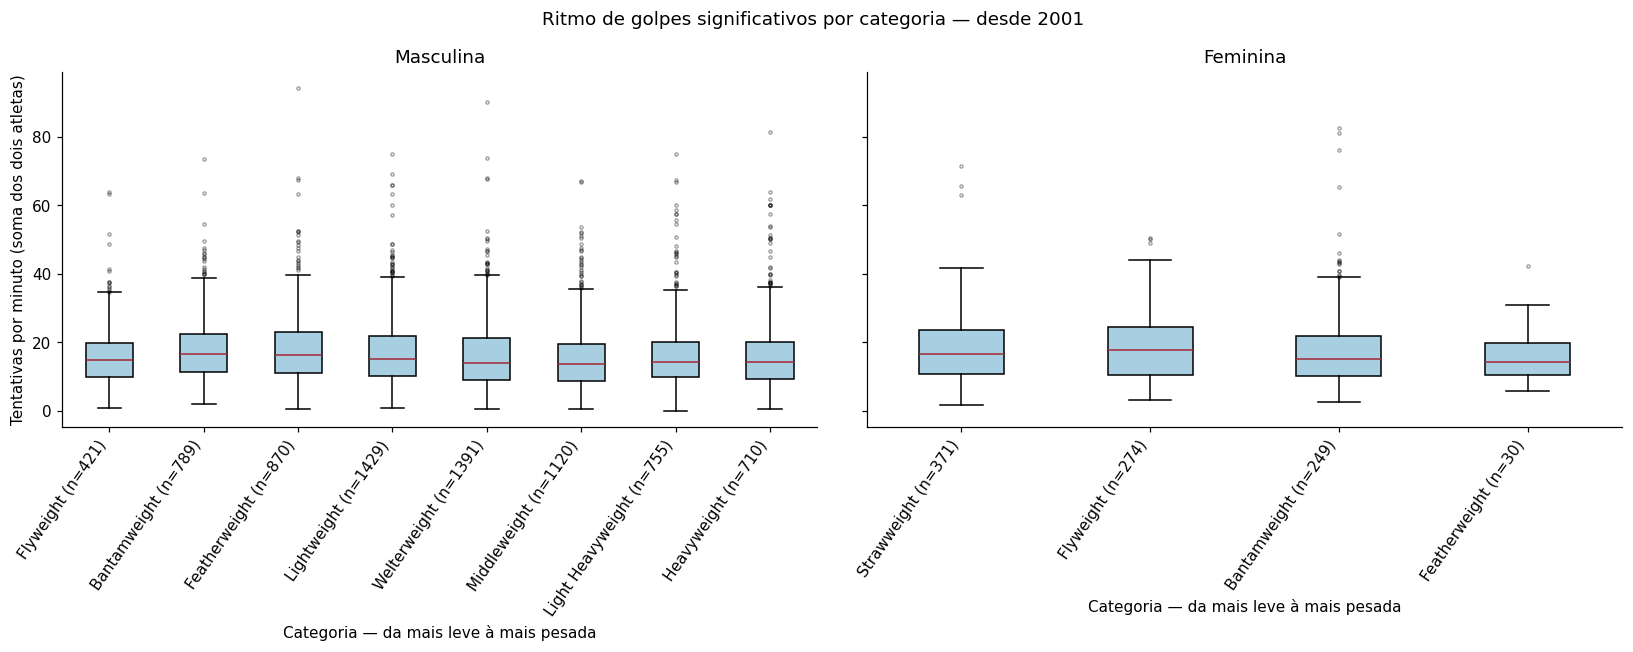

In [141]:
volume_por_peso('tentativas_por_minuto', 'Ritmo de golpes significativos por categoria — desde 2001',
                'Tentativas por minuto (soma dos dois atletas)')

## EDA — perfil dos lutadores (`dim_fighter`)

**Unidade de análise: um lutador por `fighter_id`**, independentemente de quantas vezes lutou.
Altura e peso representam os valores cadastrais da dimensão, não necessariamente os valores na primeira luta ou na pesagem de cada evento.
Altura em centímetros; peso convertido de libras para quilogramas.

Idade refere-se à **primeira luta registrada em `df_master`**, não necessariamente à estreia profissional.
O gênero é uma classificação inferida da divisão da luta em `bout_type`, não uma informação de identidade autodeclarada. Sem confronto correspondente ou rótulo utilizável, fica como `Não identificado`. Evidências feminina e masculina para o mesmo ID são marcadas como `Conflitante`.

In [142]:

# Uma linha por atleta. Para IDs repetidos, conservar a linha com menos nulos;
# empates preservam a ordem original. Exibir os registros antes da seleção.
fighters_origem = dim_fighter.copy()
if fighters_origem['fighter_id'].isna().any():
    raise ValueError('Há fighter_id ausente na dimensão; revisar antes de contar atletas.')
ids_repetidos = fighters_origem['fighter_id'].duplicated(keep=False)
if ids_repetidos.any():
    print('Registros com ID repetido — revisar divergências cadastrais:')
    display(fighters_origem.loc[ids_repetidos, [
        'fighter_id', 'fighter_name', 'height_cm', 'weight_lbs', 'date_of_birth'
    ]])
fighters_eda = (fighters_origem.assign(_nulos=fighters_origem.isna().sum(axis=1))
                .sort_values('_nulos', kind='stable')
                .drop_duplicates('fighter_id', keep='first')
                .drop(columns='_nulos').copy())
print(f'Dimensão: {len(fighters_origem):,} registros; {len(fighters_eda):,} atletas únicos.')

# Transformar os dois cantos em um histórico único de participações.
participacoes = pd.concat([
    df_master[[f'{lado}_fighter_id', 'event_date', 'bout_type']]
        .rename(columns={f'{lado}_fighter_id': 'fighter_id'})
    for lado in ['red', 'blue']
], ignore_index=True)
print('Participações sem ID, não vinculadas:', participacoes['fighter_id'].isna().sum())
participacoes = participacoes.dropna(subset=['fighter_id']).copy()
participacoes['data_luta'] = pd.to_datetime(participacoes['event_date'], errors='coerce')
rotulo = participacoes['bout_type'].astype('string').str.strip()
rotulo_valido = rotulo.notna() & rotulo.ne('')
feminina = rotulo.str.contains(r"women|female", case=False, regex=True, na=False)
participacoes['genero_luta'] = pd.Series(pd.NA, index=participacoes.index, dtype='string')
# Rótulos genéricos (Catch/Open Weight e torneios sem categoria) não informam gênero.
categoria_masculina = rotulo.str.contains(
    r'Strawweight|Flyweight|Bantamweight|Featherweight|Lightweight|Welterweight|Middleweight|Heavyweight',
    case=False, regex=True, na=False)
participacoes.loc[rotulo_valido & feminina, 'genero_luta'] = 'Feminino'
participacoes.loc[rotulo_valido & ~feminina & categoria_masculina, 'genero_luta'] = 'Masculino'

def consolidar_genero(valores):
    encontrados = set(valores.dropna())
    if not encontrados:
        return 'Não identificado'
    return next(iter(encontrados)) if len(encontrados) == 1 else 'Conflitante'

historico_fighters = participacoes.groupby('fighter_id').agg(
    primeira_luta_base=('data_luta', 'min'),
    genero_eda=('genero_luta', consolidar_genero),
    participacoes_base=('fighter_id', 'size'))
fighters_eda = fighters_eda.merge(historico_fighters, on='fighter_id', how='left',
                                 validate='one_to_one')
fighters_eda['genero_eda'] = fighters_eda['genero_eda'].fillna('Não identificado')
fighters_eda['flag_feminino'] = fighters_eda['genero_eda'].map(
    {'Feminino': 1, 'Masculino': 0}).astype('Int64')
fighters_eda['flag_masculino'] = fighters_eda['genero_eda'].map(
    {'Feminino': 0, 'Masculino': 1}).astype('Int64')
fighters_eda['nascimento_eda'] = pd.to_datetime(fighters_eda['date_of_birth'], errors='coerce')
fighters_eda['altura_cm_eda'] = pd.to_numeric(fighters_eda['height_cm'], errors='coerce')
fighters_eda['peso_kg_eda'] = pd.to_numeric(fighters_eda['weight_lbs'], errors='coerce') * 0.45359237
fighters_eda['idade_primeira_luta_anos'] = (
    (fighters_eda['primeira_luta_base'] - fighters_eda['nascimento_eda']).dt.days / 365.2425)

# Ausências e valores não positivos ficam fora das distribuições; extremos positivos são mantidos.
for coluna in ['altura_cm_eda', 'peso_kg_eda', 'idade_primeira_luta_anos']:
    invalido = fighters_eda[coluna].notna() & fighters_eda[coluna].le(0)
    print(f'{coluna}: valores não positivos excluídos = {invalido.sum()}')
    fighters_eda[coluna] = fighters_eda[coluna].mask(invalido)

print('Atletas sem participação vinculada:', fighters_eda['participacoes_base'].isna().sum())
print('Atletas sem primeira data válida:', fighters_eda['primeira_luta_base'].isna().sum())
print('Atletas sem nascimento válido:', fighters_eda['nascimento_eda'].isna().sum())
conflitos_genero = fighters_eda['genero_eda'].eq('Conflitante')
print('Atletas com evidências de gênero conflitantes:', conflitos_genero.sum())
if conflitos_genero.any():
    display(fighters_eda.loc[conflitos_genero, ['fighter_id', 'fighter_name', 'genero_eda']])

Registros com ID repetido — revisar divergências cadastrais:


,fighter_id,fighter_name,height_cm,weight_lbs,date_of_birth
2236,baa9be02c3e3e038,Jose Daniel Medina,182.88,185.000000,1991-05-17
2243,baa9be02c3e3e038,Jose Medina,182.88,184.989664,1991-05-17


Dimensão: 4,534 registros; 4,533 atletas únicos.
Participações sem ID, não vinculadas: 15
altura_cm_eda: valores não positivos excluídos = 0
peso_kg_eda: valores não positivos excluídos = 0
idade_primeira_luta_anos: valores não positivos excluídos = 0
Atletas sem participação vinculada: 1845
Atletas sem primeira data válida: 1845
Atletas sem nascimento válido: 764
Atletas com evidências de gênero conflitantes: 0


### 1. Distribuições de altura e peso
Cada atleta aparece uma vez. Histogramas mostram a forma da distribuição; a linha tracejada indica a mediana. Pesos extremos permanecem visíveis e devem ser conferidos na fonte, sem exclusão automática.

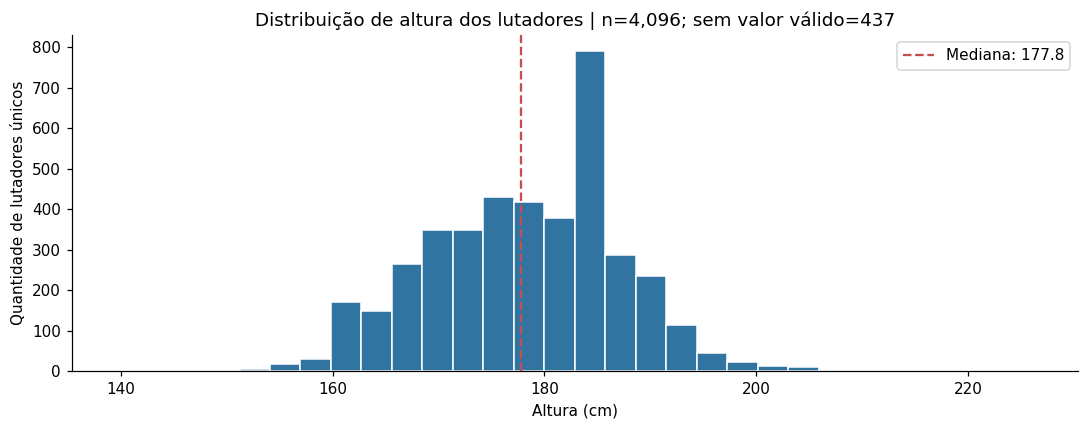

,Altura (cm)
count,4096.000000
mean,178.163389
std,8.977682
min,139.700000
25%,172.720000
50%,177.800000
75%,185.420000
max,226.060000


In [143]:
def histograma_fighters(coluna, titulo, unidade, bins=30):
    valores = fighters_eda[coluna].dropna()
    ausentes = len(fighters_eda) - len(valores)
    if valores.empty:
        print(f'{titulo}: nenhum valor válido.')
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(valores, bins=bins, color='#3274A1', edgecolor='white')
    ax.axvline(valores.median(), color='#C44E52', linestyle='--',
               label=f'Mediana: {valores.median():.1f}')
    ax.set(title=f'{titulo} | n={len(valores):,}; sem valor válido={ausentes:,}',
           xlabel=unidade, ylabel='Quantidade de lutadores únicos')
    ax.legend()
    fig.tight_layout()
    plt.show()
    display(valores.describe().to_frame(unidade))

histograma_fighters('altura_cm_eda', 'Distribuição de altura dos lutadores', 'Altura (cm)')

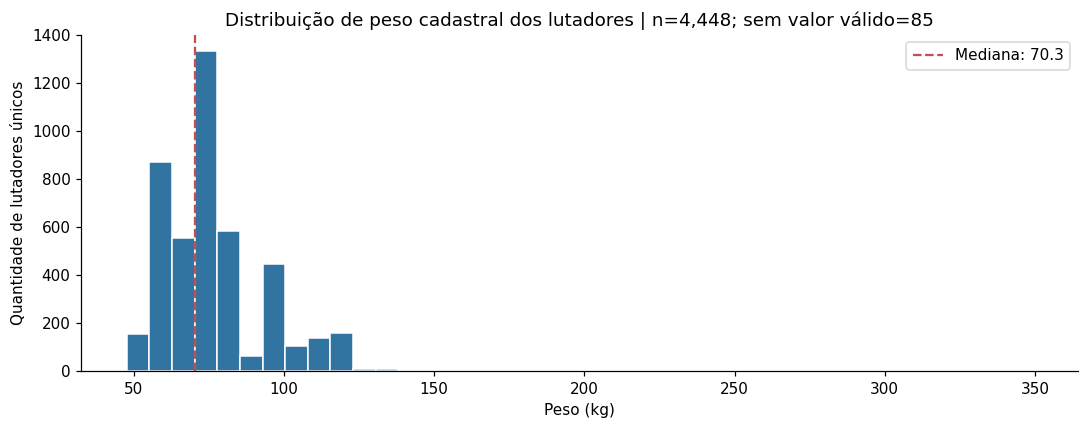

,Peso (kg)
count,4448.000000
mean,76.938871
std,17.955017
min,47.627199
25%,65.770894
50%,70.306817
75%,83.914588
max,349.266125


Maiores pesos cadastrados — conferir os extremos na fonte:


,fighter_id,fighter_name,weight_lbs,peso_kg_eda
2352,2299605af59fd309,Emmanuel Yarborough,770.0,349.266125
3138,96eff1a628adcc7f,Teila Tuli,430.0,195.044719
2767,ea398c802d9998ee,Thomas Ramirez,410.0,185.972872
2717,c933d423ebdbbbdb,John Matua,400.0,181.436948
3258,5df10509264586e5,Cory Peterson,400.0,181.436948


In [144]:
histograma_fighters('peso_kg_eda', 'Distribuição de peso cadastral dos lutadores', 'Peso (kg)', bins=40)
print('Maiores pesos cadastrados — conferir os extremos na fonte:')
display(fighters_eda.nlargest(5, 'peso_kg_eda')[
    ['fighter_id', 'fighter_name', 'weight_lbs', 'peso_kg_eda']])

### 2. Idade na primeira luta registrada
A primeira data é buscada nos dois cantos, agrupando por `fighter_id`. A idade em anos é aproximada pela diferença de dias dividida por 365,2425. Atletas sem data de nascimento ou sem luta vinculada não entram no histograma; isso limita a cobertura da análise.

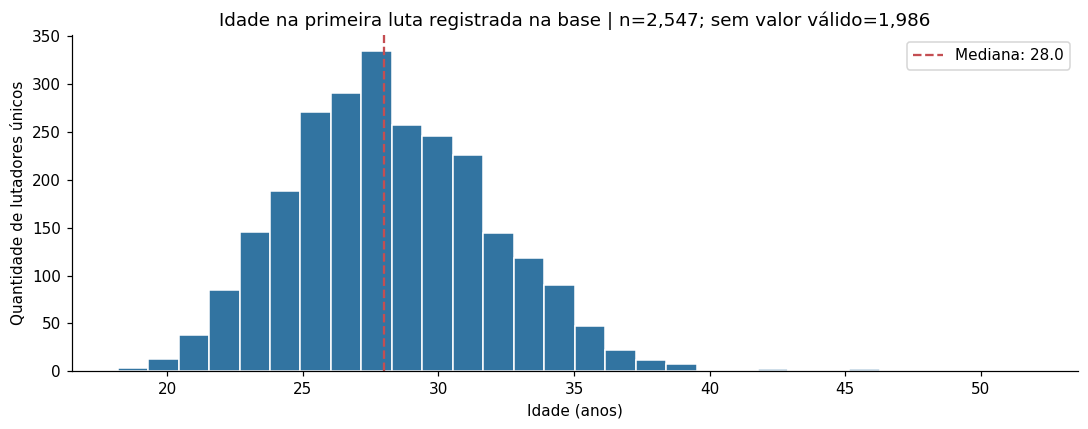

,Idade (anos)
count,2547.000000
mean,28.256649
std,3.718539
min,18.171489
25%,25.609013
50%,27.986885
75%,30.689200
max,51.891552


,fighter_name,date_of_birth,primeira_luta_base,idade_primeira_luta_anos
1092,Raul Rosas Jr.,2004-10-08,2022-12-10,18.171489
2762,Sean Daugherty,1975-12-04,1994-03-11,18.267316
2006,Dan Lauzon,1988-03-30,2006-10-14,18.541106
1163,Sage Northcutt,1996-03-01,2015-10-03,19.589725
2246,Alice Pereira,2005-12-20,2025-09-13,19.732096
2294,Chan-Mi Jeon,1997-08-28,2017-06-10,19.784116
1319,Vitor Belfort,1977-04-01,1997-02-07,19.855302
583,Jake Matthews,1994-08-19,2014-06-28,19.858040
1212,Song Yadong,1997-12-02,2017-11-25,19.981245
1755,Naoki Inoue,1997-06-14,2017-06-17,20.008624


In [145]:
histograma_fighters('idade_primeira_luta_anos',
                     'Idade na primeira luta registrada na base', 'Idade (anos)')
display(fighters_eda[['fighter_name', 'date_of_birth', 'primeira_luta_base',
                      'idade_primeira_luta_anos']]
        .sort_values('idade_primeira_luta_anos').head(10))

### 3. Distribuição por gênero inferido da divisão
O denominador inclui todos os atletas únicos da dimensão, inclusive os não identificados. As flags são 1/0 apenas quando há uma classificação única; ausência ou conflito produzem `NA`. Não atribuímos masculino automaticamente a atletas sem vínculo na base de lutas.

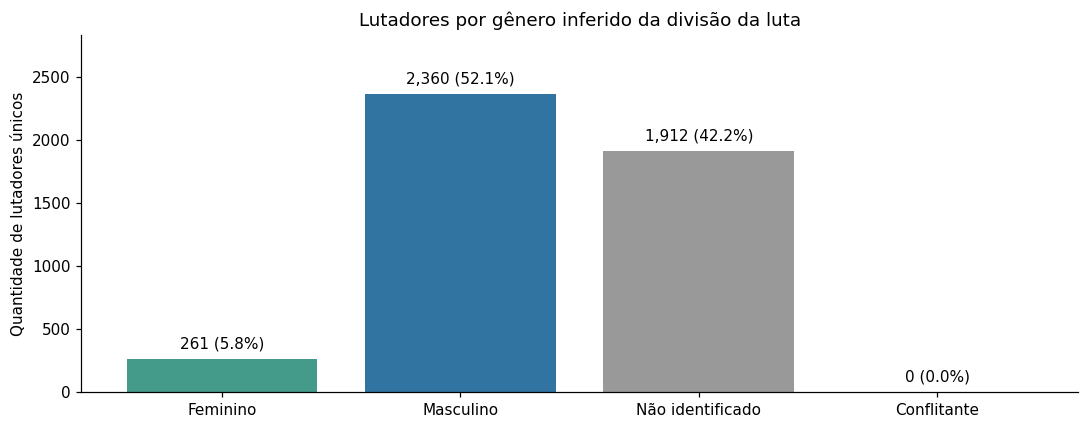

,quantidade,percentual
genero_eda,,
Feminino,261,5.757776
Masculino,2360,52.062652
Não identificado,1912,42.179572
Conflitante,0,0.0


In [146]:
ordem_genero = ['Feminino', 'Masculino', 'Não identificado', 'Conflitante']
distribuicao_genero = (fighters_eda['genero_eda'].value_counts()
                       .reindex(ordem_genero, fill_value=0).to_frame('quantidade'))
distribuicao_genero['percentual'] = distribuicao_genero['quantidade'] / len(fighters_eda) * 100
fig, ax = plt.subplots(figsize=(10, 4))
barras = ax.bar(distribuicao_genero.index, distribuicao_genero['quantidade'],
                color=['#459B8A', '#3274A1', '#999999', '#C44E52'])
ax.bar_label(barras, labels=[f'{r.quantidade:,} ({r.percentual:.1f}%)'
                            for r in distribuicao_genero.itertuples()], padding=5)
ax.set(title='Lutadores por gênero inferido da divisão da luta',
       ylabel='Quantidade de lutadores únicos',
       ylim=(0, max(distribuicao_genero['quantidade'].max() * 1.2, 1)))
fig.tight_layout()
plt.show()
display(distribuicao_genero)

### 4. Boxplots: altura, peso e idade por gênero
Usamos boxplots para comparar **mediana, dispersão e valores extremos** entre grupos. A linha dentro da caixa é a mediana; a caixa cobre os 50% centrais; pontos além dos bigodes são extremos pelo critério de 1,5 vezes a distância interquartil, não erros confirmados.

Entram apenas atletas classificados como feminino ou masculino e com valor válido para cada variável. O tamanho da amostra aparece em cada grupo. Idade refere-se à primeira luta registrada; peso e altura são cadastrais e podem ser de outra data. Gênero é categórico: para sua distribuição, usamos barras, não boxplot.

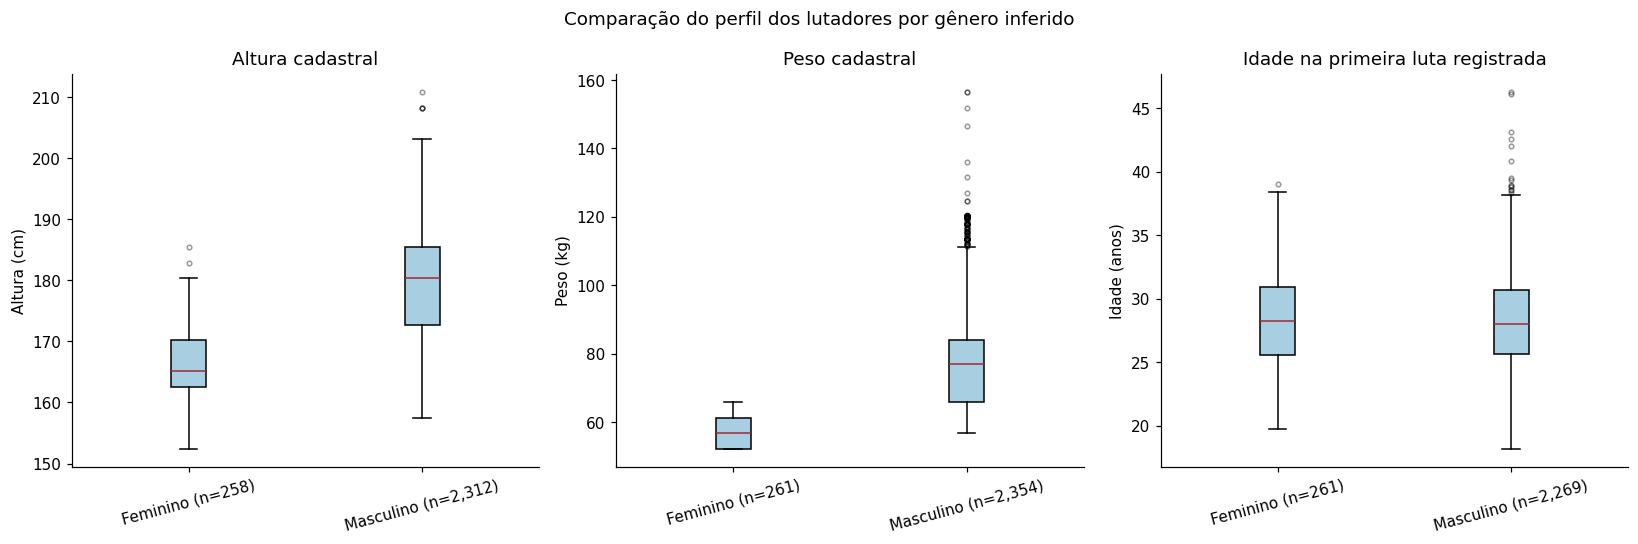

altura_cm_eda                                        \
                         count  median    mean   std     min     max   
genero_eda                                                             
Feminino                   258  165.10  165.55  5.88  152.40  185.42   
Masculino                 2312  180.34  179.59  8.04  157.48  210.82   
Não identificado          1526  177.80  178.13  9.09  139.70  226.06   

                 peso_kg_eda                                      \
                       count median   mean    std    min     max   
genero_eda                                                         
Feminino                 261  56.70  56.42   4.01  52.16   65.77   
Masculino               2354  77.11  78.03  15.94  56.70  156.49   
Não identificado        1833  77.11  78.46  19.75  47.63  349.27   

                 idade_primeira_luta_anos                                    
                                    count median   mean   std    min    max  
genero_eda                                                                   
Feminino                              261  28.20  28.24  3.91  19.73  39.01  
Masculino                            2269  27.98  28.26  3.66  18.17  46.27  
Não identificado                       17  27.53  28.48  7.25  18.27  51.89

In [153]:
variaveis_fighters = {
    'altura_cm_eda': ('Altura cadastral', 'Altura (cm)'),
    'peso_kg_eda': ('Peso cadastral', 'Peso (kg)'),
    'idade_primeira_luta_anos': ('Idade na primeira luta registrada', 'Idade (anos)')
}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (coluna, (titulo, unidade)) in zip(axes, variaveis_fighters.items()):
    grupos, amostras = [], []
    for genero in ['Feminino', 'Masculino']:
        valores = fighters_eda.loc[fighters_eda['genero_eda'].eq(genero), coluna].dropna()
        if len(valores):
            grupos.append(f'{genero} (n={len(valores):,})')
            amostras.append(valores)
    if amostras:
        ax.boxplot(amostras, patch_artist=True,
                   boxprops={'facecolor': '#A8CEE2'}, medianprops={'color': '#A32832'},
                   flierprops={'markersize': 3, 'alpha': .4})
        ax.set_xticks(range(1, len(grupos) + 1), grupos, rotation=15)
    ax.set(title=titulo, ylabel=unidade)
fig.suptitle('Comparação do perfil dos lutadores por gênero inferido')
fig.tight_layout()
plt.show()
resumo_fighters = fighters_eda.groupby('genero_eda')[list(variaveis_fighters)].agg(
    ['count', 'median', 'mean', 'std', 'min', 'max'])
display(resumo_fighters.round(2))

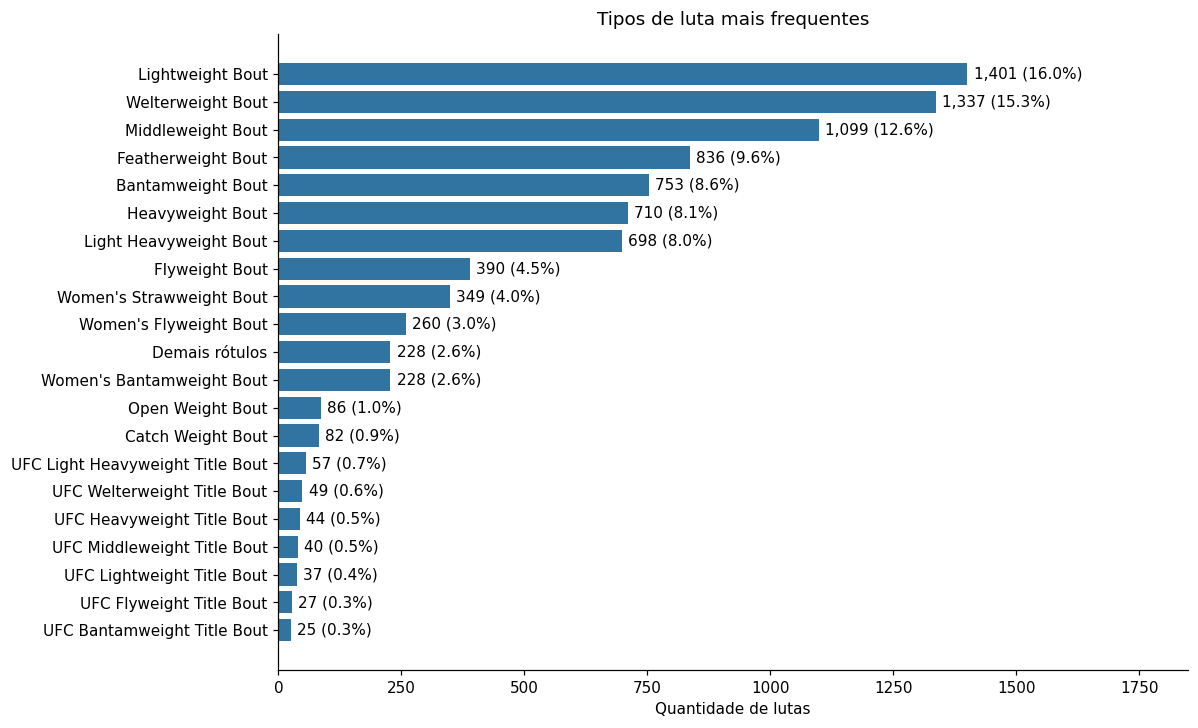

,quantidade,percentual
categoria,,
Lightweight Bout,1401,16.037088
Welterweight Bout,1337,15.304487
Middleweight Bout,1099,12.580128
Featherweight Bout,836,9.569597
Bantamweight Bout,753,8.619505
...,...,...
UFC 6 Tournament Title Bout,1,0.011447
UFC 5 Tournament Title Bout,1,0.011447
UFC 4 Tournament Title Bout,1,0.011447


In [156]:
freq_bout = frequencias(eda['bout_type'], 'Tipos de luta mais frequentes', top=20)